# Liver Disease Prediction on ILPD — Framework v2 (repeated nested CV, metric-specific thresholds, risk–coverage)




### Evidence from run 1 that justified removing sections
| Removed or changed | Run-1 evidence |
|---|---|
| Boruta+SHAP selection | Re-run inside each fold, it **lowered** AUC by 0.008 (> 1 SE). It rejected Albumin and A/G, which permutation importance ranked 1st and 3rd. |
| Clinical feature engineering | +0.0016 AUC (1 SE = 0.0046). After the Yeo-Johnson (log-like) transform, ratios are just differences of existing inputs. |
| Isolation Forest (removal or score feature) | −0.004 (removal) / −0.006 (score feature) mean AUC. Flagged patients were 78% diseased, so the flags carry signal rather than noise. |
| SMOTEENN | +0.0018 AUC (1 SE = 0.0076), while Brier worsened to 0.21–0.31. Class weights are kept. |
| Grid/Random/Optuna comparison | Tuning gained LR +0.009, ET +0.002 and LightGBM +0.017 AUC, all below the fold SD (0.07–0.08), after about 14 min of search. Replaced by pre-specified regularized settings plus a nested C for LR. |
| XGBoost, LightGBM, HGB, RF, EBM | CV AUC 0.700–0.731, the lowest group; the boosters overfit, RF duplicated ET and EBM matched LR. |
| Weighted voting, stacking | 0.731 / 0.737 multi-seed vs 0.742 for equal-weight voting; the weights overfit (CatBoost 0.83, SVM 0). |
| 5:1 cost analysis | Collapsed to "treat all" for every model and every ratio. Replaced by a sensitivity-constrained rule plus decision curve analysis. |
| 114-patient holdout | Test AUC exceeded CV for all 12 models (≈ +0.07); AUC CI ±0.08. Replaced by repeated CV with Nadeau–Bengio-corrected intervals. |

## 0. Install missing packages (before any import)
*Internet ON* is required. **TabPFN licence (one-time, needed for the current default weights):**
1. Sign in at <https://ux.priorlabs.ai>, open the **License** tab and accept the licence.
2. Copy the access token from your account there.
3. In Kaggle, open **Add-ons → Secrets**, add a secret named `TABPFN_TOKEN` with that token, and attach it to this notebook.

TabPFN reads `TABPFN_TOKEN` from the environment in headless sessions such as Kaggle. Without the secret, the notebook falls back to the older **TabPFN-v2** weights (Apache-2.0-based licence). If those cannot be loaded either, TabPFN is skipped and everything else still runs. The newer default weights are released under a **non-commercial** licence; report which variant was used (printed in Section 4).

In [3]:
# ============================================================
# 0. Install missing packages
# ============================================================
import importlib.util, subprocess, sys
OPTIONAL_PACKAGES = {"catboost": "catboost", "shap": "shap", "lime": "lime", "SALib": "SALib", "tabpfn": "tabpfn"}
missing = [pip for mod, pip in OPTIONAL_PACKAGES.items() if importlib.util.find_spec(mod) is None]
for pip_name in missing:
    try:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name], check=True, timeout=900,
                       stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        print(f"  ok   {pip_name}")
    except Exception as exc:
        print(f"  FAIL {pip_name} ({type(exc).__name__}) — dependent steps will be skipped")
print("Package check done." if not missing else f"Installed/attempted: {missing}")

Package check done.


## 1. Setup, TabPFN authentication and configuration

In [4]:
# ============================================================
# 1. Setup
# ============================================================
import os, re, json, time, math, pickle, random, warnings, importlib
from collections import OrderedDict
os.environ["PYTHONWARNINGS"] = "ignore"          # also silences joblib worker processes
warnings.filterwarnings("ignore")

# ---- TabPFN authentication: must run BEFORE tabpfn is imported ----
if not os.environ.get("TABPFN_TOKEN"):
    try:
        from kaggle_secrets import UserSecretsClient
        os.environ["TABPFN_TOKEN"] = UserSecretsClient().get_secret("TABPFN_TOKEN")
        print("TabPFN token loaded from Kaggle Secrets.")
    except Exception:
        print("[INFO] No TABPFN_TOKEN secret attached — will try the TabPFN-v2 weights instead.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import rankdata
from joblib import Parallel, delayed
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 250)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

def opt_import(name):
    try:
        return importlib.import_module(name)
    except Exception as exc:
        print(f"[WARN] {name} unavailable ({type(exc).__name__}: {str(exc)[:80]})")
        return None

cb = opt_import("catboost")
shap = opt_import("shap")
tabpfn = opt_import("tabpfn")
lime_tabular = opt_import("lime.lime_tabular")
salib_sample = opt_import("SALib.sample.morris")
salib_analyze = opt_import("SALib.analyze.morris")

import sklearn
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin, clone
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, PowerTransformer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor, VotingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix, cohen_kappa_score,
                             brier_score_loss, matthews_corrcoef)
from sklearn.calibration import calibration_curve

# ---------------- Configuration ----------------
SEED = 42
N_JOBS = -1
N_FOLDS, N_REPEATS = 10, 10      # outer: repeated stratified 10-fold x 10
INNER_FOLDS = 5                  # inner CV: thresholds and LR's C
SENS_TARGET = 0.90               # clinical rule: sensitivity >= target, then maximise specificity
INCLUDE_SVM_ABLATION = True
TABPFN_BUDGET_MIN = 90           # TabPFN is skipped if its estimated nested-CV time exceeds this
LC_FRACTIONS = [0.25, 0.4, 0.55, 0.7, 0.85, 1.0]
LC_REPEATS = 4                   # learning curve: 5-fold x LC_REPEATS
NOISE_REPEATS = 5                # label-noise and parsimony experiments use the first repeats
NOISE_HIGH, NOISE_LOW = 0.90, 0.25   # suspicious: label 0 with P>=0.90, or label 1 with P<=0.25 (calibrated)
SHAP_TIME_BUDGET_S = 300
LIME_TIME_BUDGET_S = 180
FAST_MODE = False                # True = quick dry run
if FAST_MODE:
    N_REPEATS, LC_REPEATS, NOISE_REPEATS = 2, 2, 2
NOISE_REPEATS = min(NOISE_REPEATS, N_REPEATS)

random.seed(SEED); np.random.seed(SEED); os.environ["PYTHONHASHSEED"] = str(SEED)
OUT_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else "./outputs"
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150, "axes.titleweight": "bold"})
def save_fig(name):
    plt.savefig(os.path.join(FIG_DIR, f"{name}.png"), bbox_inches="tight")

EVIDENCE = OrderedDict()
T_START = time.time()
print(f"numpy {np.__version__} | pandas {pd.__version__} | sklearn {sklearn.__version__}")
for _n, _m in [("catboost", cb), ("shap", shap), ("tabpfn", tabpfn), ("lime", lime_tabular), ("SALib", salib_sample)]:
    print(f"  {_n:<9}: {'available' if _m is not None else 'NOT available'}")

[INFO] No TABPFN_TOKEN secret attached — will try the TabPFN-v2 weights instead.
numpy 2.0.2 | pandas 2.3.3 | sklearn 1.6.1
  catboost : available
  shap     : available
  tabpfn   : available
  lime     : available
  SALib    : available


## 2. Data loading with content-based column verification (unchanged from v1)
The Kaggle headers are shifted relative to the values, so column meaning is established from content: physiological ranges plus the A/G = Albumin/(TP − Albumin) identity. Exact duplicates are removed so that no patient can appear in both a training and a validation fold.

In [5]:
# ============================================================
# 2. Data loading and semantic verification
# ============================================================
DATA_DIR = "/kaggle/input/datasets/jeevannagaraj/indian-liver-patient-dataset"
SUPPORTED = (".csv", ".tsv", ".txt", ".data", ".xlsx", ".xls")
CANON = ["Age", "Gender", "Total_Bilirubin", "Direct_Bilirubin", "Alkaline_Phosphatase",
         "ALT", "AST", "Total_Proteins", "Albumin", "AG_Ratio", "Target"]      # UCI ILPD column order

def discover(root):
    return sorted(os.path.join(d, f) for d, _, fs in os.walk(root) for f in fs if f.lower().endswith(SUPPORTED))

files = discover(DATA_DIR) if os.path.isdir(DATA_DIR) else []
if not files and os.path.isdir("/kaggle/input"):
    allf = discover("/kaggle/input")
    files = [f for f in allf if any(k in f.lower() for k in ("liver", "ilpd"))] or allf
if not files:
    raise FileNotFoundError("ILPD file not found — attach the dataset via 'Add Input'.")
DATA_PATH = max(files, key=lambda p: (int(any(k in os.path.basename(p).lower() for k in ("liver", "ilpd", "patient"))),
                                      os.path.getsize(p)))
print("Data file:", DATA_PATH)

def read_any(path, header="infer"):
    if path.lower().endswith((".xlsx", ".xls")):
        return pd.read_excel(path, header=0 if header == "infer" else None)
    try:
        return pd.read_csv(path, sep=None, engine="python", header=header)
    except Exception:
        return pd.read_csv(path, header=header)

def looks_headerless(frame):
    def is_num(x):
        try:
            float(str(x)); return True
        except ValueError:
            return False
    return sum(is_num(c) for c in frame.columns) >= max(2, frame.shape[1] // 2)

raw = read_any(DATA_PATH)
if looks_headerless(raw):
    raw = read_any(DATA_PATH, header=None)
raw = raw.dropna(how="all").dropna(axis=1, how="all")
raw.columns = [str(c).strip() for c in raw.columns]
for c in list(raw.columns):
    s = pd.to_numeric(raw[c], errors="coerce")
    if c.lower().startswith("unnamed") and s.notna().all() and (s.diff().dropna() == 1).all():
        raw = raw.drop(columns=c)
raw = raw.reset_index(drop=True)
print("Raw shape:", raw.shape, "| headers:", list(raw.columns))

def _norm(s):
    return re.sub(r"[^a-z0-9]", "", str(s).lower())
TARGET_KEYS = {"dataset", "selector", "selectorfield", "target", "class", "label", "outcome", "result",
               "liverpatient", "isliverpatient", "ispatient", "diagnosis", "disease", "liverdisease"}
HEADER_RULES = [
    ("Target",               lambda n: n in TARGET_KEYS),
    ("Age",                  lambda n: n == "age" or n.startswith("ageof")),
    ("Gender",               lambda n: n in {"gender", "sex"} or n.startswith("genderof")),
    ("Direct_Bilirubin",     lambda n: ("bilirubin" in n and "direct" in n) or n in {"db", "dbil"}),
    ("Total_Bilirubin",      lambda n: ("bilirubin" in n and ("total" in n or n.startswith("tot"))) or n in {"tb", "tbil"}),
    ("Alkaline_Phosphatase", lambda n: "phosph" in n or n in {"alkphos", "alp"}),
    ("ALT",                  lambda n: "sgpt" in n or "alamine" in n or "alanine" in n or n == "alt"),
    ("AST",                  lambda n: "sgot" in n or "aspartate" in n or n == "ast"),
    ("AG_Ratio",             lambda n: "globulin" in n or n in {"agratio", "ag"}),
    ("Total_Proteins",       lambda n: "prot" in n or n == "tp"),
    ("Albumin",              lambda n: "albumin" in n or "albamin" in n or n == "alb"),
]
def header_mapping(columns):
    mapping, used = {}, set()
    for col in columns:
        n = _norm(col)
        for canon, rule in HEADER_RULES:
            if canon not in used and rule(n):
                mapping[col] = canon; used.add(canon); break
    return mapping

def validate_semantics(frame):
    checks = []
    def chk(name, cond):
        checks.append({"check": name, "passed": bool(cond)})
    num = lambda c: pd.to_numeric(frame[c], errors="coerce")
    try:
        g = frame["Gender"].astype(str).str.strip().str.lower()
        chk("Gender holds Male/Female values", g.isin(["male", "female", "m", "f"]).mean() > 0.95)
        tb, db = num("Total_Bilirubin"), num("Direct_Bilirubin")
        chk("Direct <= Total bilirubin (>=98% rows)", (db <= tb + 1e-9).mean() >= 0.98)
        tp, alb, ag = num("Total_Proteins"), num("Albumin"), num("AG_Ratio")
        chk("Total protein median in 5-9 g/dL", 5 <= tp.median() <= 9)
        chk("Albumin median in 2-5 g/dL", 2 <= alb.median() <= 5)
        chk("Albumin < Total protein (>=98% rows)", (alb < tp).mean() >= 0.98)
        calc = alb / (tp - alb).where(tp - alb > 0)
        rel = ((ag - calc).abs() / calc).dropna()
        chk("A/G = Albumin/(TP - Albumin) (median rel. error < 10%)", len(rel) > 0 and rel.median() < 0.10)
        chk("ALP median > 100 IU/L", num("Alkaline_Phosphatase").median() > 100)
        chk("ALT and AST medians in 10-200 IU/L", all(10 <= num(c).median() <= 200 for c in ["ALT", "AST"]))
        chk("Target is binary", frame["Target"].dropna().nunique() == 2)
    except Exception as exc:
        chk(f"required columns usable ({type(exc).__name__}: {exc})", False)
    rep = pd.DataFrame(checks)
    return bool(rep["passed"].all()), rep

attempts = []
hmap = header_mapping(raw.columns)
if set(CANON).issubset(hmap.values()):
    attempts.append(("header names", hmap))
if raw.shape[1] == len(CANON):
    attempts.append(("UCI column order (positional)", dict(zip(raw.columns, CANON))))
CHOSEN = None
for label_, mapping in attempts:
    cand = raw.rename(columns=mapping)[CANON].copy()
    ok, rep = validate_semantics(cand)
    print(f"Mapping by {label_}: {'PASSED' if ok else 'FAILED'} ({int(rep['passed'].sum())}/{len(rep)} checks)")
    if ok and CHOSEN is None:
        CHOSEN = (label_, mapping, cand)
if CHOSEN is None:
    raise ValueError("No clinically consistent column mapping found.")
MAP_LABEL, COL_MAP, df = CHOSEN
map_table = pd.DataFrame([{"file_header": k, "assigned_variable": v, "header_suggests": hmap.get(k, "-"),
                           "median": pd.to_numeric(raw[k], errors="coerce").median(),
                           "n_missing": int(raw[k].isna().sum())} for k, v in COL_MAP.items()])
mismatch = map_table[(map_table["header_suggests"] != "-") & (map_table["header_suggests"] != map_table["assigned_variable"])]
print(f"Accepted mapping: {MAP_LABEL} | overridden headers: {len(mismatch)}")
display(map_table)
EVIDENCE["column_mapping"] = {"method": MAP_LABEL, "overridden_headers": mismatch[["file_header", "assigned_variable"]].values.tolist()}

t = pd.to_numeric(df["Target"], errors="coerce")
vals = set(t.dropna().unique().tolist())
if vals == {1, 2}:
    df["Target"] = (t == 1).astype(float).where(t.notna())
elif vals <= {0, 1}:
    df["Target"] = t
else:
    raise ValueError(f"Unexpected target values: {vals}")
df = df[df["Target"].notna()].copy()
df["Target"] = df["Target"].astype(int)
g = df["Gender"].astype(str).str.strip().str.lower()
df["Gender"] = np.where(g.isin(["male", "m"]), "Male", np.where(g.isin(["female", "f"]), "Female", None))
for c in CANON:
    if c not in ("Gender", "Target"):
        df[c] = pd.to_numeric(df[c], errors="coerce")

FEATURES = [c for c in CANON if c != "Target"]
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {n_before - len(df)} exact duplicates -> {len(df)} unique patients; "
      f"prevalence {df['Target'].mean():.3f}")
EVIDENCE["data"] = {"rows_raw": n_before, "rows_unique": len(df), "prevalence": round(float(df["Target"].mean()), 4)}

Data file: /kaggle/input/datasets/jeevannagaraj/indian-liver-patient-dataset/Indian Liver Patient Dataset (ILPD).csv
Raw shape: (583, 11) | headers: ['age', 'gender', 'tot_bilirubin', 'direct_bilirubin', 'tot_proteins', 'albumin', 'ag_ratio', 'sgpt', 'sgot', 'alkphos', 'is_patient']
Mapping by header names: FAILED (3/9 checks)
Mapping by UCI column order (positional): PASSED (9/9 checks)
Accepted mapping: UCI column order (positional) | overridden headers: 6


,file_header,assigned_variable,header_suggests,median,n_missing
0,age,Age,Age,45.0000,0
1,gender,Gender,Gender,NaN,0
2,tot_bilirubin,Total_Bilirubin,Total_Bilirubin,1.0000,0
3,direct_bilirubin,Direct_Bilirubin,Direct_Bilirubin,0.3000,0
4,tot_proteins,Alkaline_Phosphatase,Total_Proteins,208.0000,0
5,albumin,ALT,Albumin,35.0000,0
6,ag_ratio,AST,AG_Ratio,42.0000,0
7,sgpt,Total_Proteins,ALT,6.6000,0
8,sgot,Albumin,AST,3.1000,0
9,alkphos,AG_Ratio,Alkaline_Phosphatase,0.9300,4


Removed 13 exact duplicates -> 570 unique patients; prevalence 0.712


## 3. Encoding and preprocessing components
`LabelEncoder` maps Female → 0 and Male → 1. The mapping carries no statistics, so fitting it on all rows cannot leak information.

All *fitted* preprocessing lives in `ClinicalPreprocessor` and is re-fitted inside every training fold:
1. deterministic A/G repair (row-wise);
2. MICE imputation with an Extra Trees estimator, kept as a safety net (after the repair nothing is missing);
3. Yeo-Johnson transform plus standardization of continuous features.

Models without class-weight support are wrapped in `BalancedPriorClassifier`, so every model outputs probabilities on the same balanced-prior scale. Calibrated probabilities are recovered per fold with the training-fold prevalence.

In [6]:
# ============================================================
# 3. Encoding + fold-safe preprocessing components
# ============================================================
X = df[FEATURES].copy()
y = df["Target"].values.astype(int)
GENDER_ENCODER = LabelEncoder().fit(X["Gender"].dropna().astype(str))
GENDER_LUT = {cls: float(i) for i, cls in enumerate(GENDER_ENCODER.classes_)}
X["Gender"] = X["Gender"].map(lambda v: GENDER_LUT.get(str(v), np.nan) if pd.notna(v) else np.nan)
X = X.astype(float)
N, PI_ALL = len(y), float(y.mean())
print("Gender encoding:", GENDER_LUT, "| X shape:", X.shape, "| missing cells:", int(X.isna().sum().sum()))

def shift_prior(p, from_prior, to_prior):
    """Bayes prior-shift correction (Saerens et al., 2002)."""
    p = np.clip(np.asarray(p, float), 1e-6, 1 - 1e-6)
    odds = p / (1 - p) * (to_prior / (1 - to_prior)) / (from_prior / (1 - from_prior))
    return odds / (1 + odds)

def repair_ag(X):
    X = X.copy()
    if {"AG_Ratio", "Albumin", "Total_Proteins"} <= set(X.columns):
        glob = X["Total_Proteins"] - X["Albumin"]
        X["AG_Ratio"] = X["AG_Ratio"].fillna(X["Albumin"] / glob.where(glob > 0))
    return X

class ClinicalPreprocessor(BaseEstimator, TransformerMixin):
    """A/G repair -> MICE (Extra Trees) -> Yeo-Johnson + standardisation of continuous features."""
    def __init__(self, power_transform=True, random_state=SEED):
        self.power_transform = power_transform
        self.random_state = random_state

    def _as_frame(self, X):
        if isinstance(X, pd.DataFrame):
            return X[self.input_columns_].astype(float)
        return pd.DataFrame(np.asarray(X, dtype=float), columns=self.input_columns_)

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("ClinicalPreprocessor must be fitted on a DataFrame")
        self.input_columns_ = list(X.columns)
        Z = repair_ag(X.astype(float))
        self.imputer_ = IterativeImputer(
            estimator=ExtraTreesRegressor(n_estimators=100, min_samples_leaf=2, n_jobs=1, random_state=self.random_state),
            initial_strategy="median", max_iter=10, skip_complete=True, random_state=self.random_state)
        Zi = self.imputer_.fit_transform(Z.values)
        self.cont_idx_ = [i for i, c in enumerate(self.input_columns_) if Z[c].nunique(dropna=True) > 2]
        self.pt_ = (PowerTransformer(method="yeo-johnson", standardize=True).fit(Zi[:, self.cont_idx_])
                    if self.power_transform and self.cont_idx_ else None)
        return self

    def transform(self, X):
        X = self._as_frame(X)
        Zi = self.imputer_.transform(repair_ag(X).values)
        if self.pt_ is not None:
            Zi[:, self.cont_idx_] = self.pt_.transform(Zi[:, self.cont_idx_])
        return pd.DataFrame(Zi, columns=self.input_columns_, index=X.index)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.input_columns_, dtype=object)

class BalancedPriorClassifier(ClassifierMixin, BaseEstimator):
    """For models without class weights: rescale probabilities to balanced priors (training-fold prevalence)."""
    def __init__(self, estimator=None):
        self.estimator = estimator
    def fit(self, X, y):
        y = np.asarray(y).astype(int)
        self.estimator_ = clone(self.estimator).fit(X, y)
        self.classes_ = np.array([0, 1])
        self.prior_ = float(y.mean())
        return self
    def predict_proba(self, X):
        pb = shift_prior(self.estimator_.predict_proba(X)[:, 1], self.prior_, 0.5)
        return np.column_stack([1 - pb, pb])
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

Gender encoding: {'Female': 0.0, 'Male': 1.0} | X shape: (570, 10) | missing cells: 4


## 4. Models (pre-specified, regularized) and TabPFN check
The settings are **pre-specified from run-1 evidence** and are not searched here. Only LR's penalty is data-driven, and it is chosen by an inner 5-fold CV inside every training fold (`LogisticRegressionCV`).

Honest caveat: run 1 tuned on 456 of these same 570 patients, so the fixed settings involve mild data reuse. The optimism is bounded by what tuning achieved in run 1 (≤ 0.017 AUC, below the fold SD). Report this in the paper.

| Model | Settings | Why |
|---|---|---|
| L2 logistic regression | C ∈ 10⁻⁴…10¹ (16 values), inner CV on AUC | Best-calibrated and most stable model in run 1 (seed SD 0.004); run 1 chose heavy shrinkage |
| Extra Trees | 500 trees, min_samples_leaf 5, max_features 0.5 | Different error pattern from LR (few FN); strong bagging keeps variance low |
| CatBoost | depth 4, lr 0.03, 400 iterations, l2 10, Bernoulli subsample 0.8 | Best booster in run 1; shallow and strongly regularized because deeper boosters overfit |
| SVM-RBF *(ablation)* | C 0.72, gamma 0.0021 (run-1 Optuna optimum) | Run 1 found it nearly linear and redundant with LR (weight 0); tested as an add-on only |
| TabPFN *(add-on)* | Pretrained; prior-balanced; default weights, else v2 | Strong prior for n < 1,000; never ran in run 1 because of the licence |

In [7]:
# ============================================================
# 4. Model factory
# ============================================================
SHORT = {"LogisticRegression": "LR", "ExtraTrees": "ET", "CatBoost": "CatBoost", "SVM-RBF": "SVM", "TabPFN": "TabPFN"}

TABPFN_VARIANT = "default"         # set by the licence check below: "default" or "v2"

def make_tabpfn(seed=SEED, variant=None):
    from tabpfn import TabPFNClassifier
    variant = TABPFN_VARIANT if variant is None else variant
    device = "cpu"
    try:
        import torch
        device = "cuda" if torch.cuda.is_available() else "cpu"
    except Exception:
        pass
    if variant == "v2":
        from tabpfn.constants import ModelVersion
        est = TabPFNClassifier.create_default_for_version(ModelVersion.V2)
        for k, v in (("device", device), ("random_state", seed)):
            try:
                est.set_params(**{k: v})
            except Exception:
                pass
        return est
    for kwargs in ({"device": device, "random_state": seed}, {"random_state": seed}, {}):
        try:
            return TabPFNClassifier(**kwargs)
        except TypeError:
            continue
    raise RuntimeError("Could not construct TabPFNClassifier")

def build_member(name, seed=SEED):
    if name == "LogisticRegression":
        est = LogisticRegressionCV(Cs=np.logspace(-4, 1, 16), cv=StratifiedKFold(INNER_FOLDS, shuffle=True, random_state=seed),
                                   scoring="roc_auc", class_weight="balanced", max_iter=5000, n_jobs=1)
    elif name == "ExtraTrees":
        est = ExtraTreesClassifier(n_estimators=500, min_samples_leaf=5, max_features=0.5, class_weight="balanced",
                                   n_jobs=1, random_state=seed)
    elif name == "CatBoost":
        est = cb.CatBoostClassifier(iterations=400, depth=4, learning_rate=0.03, l2_leaf_reg=10, bootstrap_type="Bernoulli",
                                    subsample=0.8, auto_class_weights="Balanced", verbose=0, thread_count=1,
                                    allow_writing_files=False, random_seed=seed)
    elif name == "SVM-RBF":
        est = SVC(kernel="rbf", C=0.72, gamma=0.0021, probability=True, class_weight="balanced", random_state=seed)
    elif name == "TabPFN":
        est = BalancedPriorClassifier(make_tabpfn(seed))
    else:
        raise ValueError(name)
    return Pipeline([("prep", ClinicalPreprocessor(random_state=seed)), ("model", est)])

CORE = ["LogisticRegression", "ExtraTrees"] + (["CatBoost"] if cb is not None else [])
MODELS = list(CORE) + (["SVM-RBF"] if INCLUDE_SVM_ABLATION else [])

# ---- TabPFN: licence/weights check + runtime budget ----
TABPFN_OK = False
if tabpfn is not None:
    _tr, _va = next(StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED).split(X, y))
    for _variant in ("default", "v2"):
        try:
            TABPFN_VARIANT = _variant
            build_member("TabPFN").fit(X.iloc[_tr], y[_tr]).predict_proba(X.iloc[_va])   # first call downloads weights
            print(f"TabPFN weights loaded: {_variant}")
            break
        except Exception as exc:
            print(f"[INFO] TabPFN '{_variant}' weights unavailable: {type(exc).__name__}: {str(exc)[:200]}")
            TABPFN_VARIANT = None
    try:
        if TABPFN_VARIANT is None:
            raise RuntimeError("no TabPFN weights could be loaded")
        t0 = time.perf_counter()
        build_member("TabPFN").fit(X.iloc[_tr], y[_tr]).predict_proba(X.iloc[_va])
        t_one = time.perf_counter() - t0
        est_min = t_one * (1 + INNER_FOLDS) * N_FOLDS * N_REPEATS / 60
        print(f"TabPFN works: {t_one:.2f}s per fit+predict -> estimated {est_min:.0f} min for the nested repeated CV")
        if est_min <= TABPFN_BUDGET_MIN:
            TABPFN_OK = True
            MODELS.append("TabPFN")
        else:
            print(f"[INFO] TabPFN skipped: above TABPFN_BUDGET_MIN={TABPFN_BUDGET_MIN}. Enable a GPU accelerator, "
                  "raise the budget or lower N_REPEATS.")
    except Exception as exc:
        print(f"[WARN] TabPFN unavailable: {type(exc).__name__}: {str(exc)[:300]}\n"
              "       Add the TABPFN_TOKEN Kaggle secret (see Section 0) after accepting the licence at ux.priorlabs.ai.")
print("Core ensemble members:", CORE)
print("All evaluated models:", MODELS)
EVIDENCE["models"] = {"core": CORE, "evaluated": MODELS, "tabpfn_available": TABPFN_OK,
                      "tabpfn_variant": TABPFN_VARIANT if TABPFN_OK else None}

[INFO] TabPFN 'default' weights unavailable: TabPFNLicenseError: TabPFN requires a one-time license acceptance to download
model weights for local inference, but no interactive terminal
is available.

To authenticate in a non-interactive environment:
  1. Open http


tabpfn-v2-classifier-finetuned-zk73skhh.(…):   0%|          | 0.00/29.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

TabPFN weights loaded: v2
TabPFN works: 0.47s per fit+predict -> estimated 5 min for the nested repeated CV
Core ensemble members: ['LogisticRegression', 'ExtraTrees', 'CatBoost']
All evaluated models: ['LogisticRegression', 'ExtraTrees', 'CatBoost', 'SVM-RBF', 'TabPFN']


## 5. Repeated nested cross-validation engine
For each of the 100 outer folds (10 folds × 10 repeats; model seeds change with each repeat) and each model, the engine records:
- probabilities on the outer validation fold;
- **inner out-of-fold probabilities on the training part** (5-fold, same inner split for every model), used to choose thresholds;
- in-sample training probabilities, used for the overfitting gap;
- fit and prediction times.

Ensembles are the equal-weight average of member probabilities (and of member inner OOFs), so any combination can be evaluated without refitting and without leakage.

In [8]:
# ============================================================
# 5. Engine
# ============================================================
RSKF = RepeatedStratifiedKFold(n_splits=N_FOLDS, n_repeats=N_REPEATS, random_state=SEED)
OUTER = [(i // N_FOLDS, i % N_FOLDS, tr, va) for i, (tr, va) in enumerate(RSKF.split(X, y))]
N_TE = N / N_FOLDS; N_TR = N - N_TE

def _run_fold(name, r, tr, va, X, y):
    seed = SEED + r
    Xtr, ytr, Xva = X.iloc[tr], y[tr], X.iloc[va]
    t0 = time.perf_counter(); pipe = build_member(name, seed).fit(Xtr, ytr); t_fit = time.perf_counter() - t0
    t0 = time.perf_counter(); p_va = pipe.predict_proba(Xva)[:, 1]; t_pred = time.perf_counter() - t0
    p_tr = pipe.predict_proba(Xtr)[:, 1]
    inner = np.zeros(len(tr))
    for itr, iva in StratifiedKFold(INNER_FOLDS, shuffle=True, random_state=seed).split(Xtr, ytr):
        inner[iva] = build_member(name, seed).fit(Xtr.iloc[itr], ytr[itr]).predict_proba(Xtr.iloc[iva])[:, 1]
    return {"p_va": p_va, "p_tr": p_tr, "inner": inner, "t_fit": t_fit, "t_pred": t_pred}

RES = OrderedDict()
for name in MODELS:
    t0 = time.time()
    RES[name] = Parallel(n_jobs=1 if name == "TabPFN" else N_JOBS)(
        delayed(_run_fold)(name, r, tr, va, X, y) for r, k, tr, va in OUTER)
    aucs = [roc_auc_score(y[va], RES[name][f]["p_va"]) for f, (r, k, tr, va) in enumerate(OUTER)]
    print(f"{name:<20} AUC {np.mean(aucs):.4f} ± {np.std(aucs, ddof=1):.4f}   ({time.time() - t0:.0f}s)")

def combo(members, f, key):
    return np.mean([RES[m][f][key] for m in members], axis=0)

VIEWS = OrderedDict((m, [m]) for m in MODELS)
def ens_name(members):
    return "Ensemble: " + "+".join(SHORT[m] for m in members)
CORE_VIEW = ens_name(CORE)
VIEWS[CORE_VIEW] = CORE
if "SVM-RBF" in MODELS:
    VIEWS[ens_name(CORE + ["SVM-RBF"])] = CORE + ["SVM-RBF"]
if "TabPFN" in MODELS:
    VIEWS[ens_name(CORE + ["TabPFN"])] = CORE + ["TabPFN"]
print("Views evaluated:", list(VIEWS))

LogisticRegression   AUC 0.7475 ± 0.0574   (76s)
ExtraTrees           AUC 0.7545 ± 0.0583   (178s)
CatBoost             AUC 0.7253 ± 0.0611   (71s)
SVM-RBF              AUC 0.7505 ± 0.0582   (18s)
TabPFN               AUC 0.7461 ± 0.0597   (312s)
Views evaluated: ['LogisticRegression', 'ExtraTrees', 'CatBoost', 'SVM-RBF', 'TabPFN', 'Ensemble: LR+ET+CatBoost', 'Ensemble: LR+ET+CatBoost+SVM', 'Ensemble: LR+ET+CatBoost+TabPFN']


## 6. Metric-specific thresholds, chosen inside each training fold
| Rule | Chosen on inner OOF predictions to… |
|---|---|
| Accuracy-optimal | maximize accuracy (the Kaggle-style headline metric) |
| Balanced-accuracy-optimal | maximize (sensitivity + specificity)/2, i.e. the Youden point |
| Sensitivity ≥ 0.90 | reach sensitivity ≥ 0.90, then maximize specificity (the clinical screening rule; replaces the v1 5:1 cost analysis) |
| Fixed 0.5 (balanced scale) | none — kept for continuity with v1 |

The chosen threshold is then applied, unchanged, to the outer validation fold.

In [9]:
# ============================================================
# 6. Threshold selection + fold-level evaluation
# ============================================================
THR_GRID = np.linspace(0.01, 0.99, 197)
RULES = OrderedDict([("accuracy", "Accuracy-optimal"), ("balanced_accuracy", "Balanced-accuracy-optimal"),
                     ("sensitivity", f"Sensitivity >= {SENS_TARGET:.2f}"), ("fixed_0.5", "Fixed 0.5 (balanced scale)")])

def pick_threshold(y_in, p_in, rule):
    if rule == "fixed_0.5":
        return 0.5
    y_in = np.asarray(y_in).astype(int); pos = y_in == 1; neg = ~pos
    pred = np.asarray(p_in)[None, :] >= THR_GRID[:, None]
    tpr = (pred & pos).sum(1) / max(pos.sum(), 1)
    tnr = (~pred & neg).sum(1) / max(neg.sum(), 1)
    if rule == "accuracy":
        score = (pred == pos).mean(1)
    elif rule == "balanced_accuracy":
        score = (tpr + tnr) / 2
    elif rule == "sensitivity":
        ok = tpr >= SENS_TARGET
        if not ok.any():
            return float(THR_GRID[0])
        score = np.where(ok, tnr, -1.0)
    else:
        raise ValueError(rule)
    best = np.flatnonzero(score >= score.max() - 1e-12)
    return float(np.median(THR_GRID[best]))

def metrics_at(yv, p, thr):
    yv = np.asarray(yv).astype(int); pred = (np.asarray(p) >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(yv, pred, labels=[0, 1]).ravel()
    sd = lambda a, b: a / b if b else 0.0
    prec, rec, tnr = sd(tp, tp + fp), sd(tp, tp + fn), sd(tn, tn + fp)
    return {"Accuracy": sd(tp + tn, len(yv)), "Precision": prec, "Recall_TPR": rec, "F1": sd(2 * prec * rec, prec + rec),
            "FPR": sd(fp, fp + tn), "FNR": sd(fn, fn + tp), "TNR": tnr, "Balanced_Acc": (rec + tnr) / 2,
            "MCC": matthews_corrcoef(yv, pred), "Kappa": cohen_kappa_score(yv, pred), "TN": tn, "FP": fp, "FN": fn, "TP": tp}

ROWS = []
PRED0 = {v: {r_: np.full(N, -1) for r_ in RULES} for v in VIEWS}       # repeat-0 predictions (one per patient)
PROB0 = {v: np.full(N, np.nan) for v in VIEWS}
for view, members in VIEWS.items():
    for f, (r, k, tr, va) in enumerate(OUTER):
        p_va, p_in, p_tr = combo(members, f, "p_va"), combo(members, f, "inner"), combo(members, f, "p_tr")
        prior = float(y[tr].mean()); yv = y[va]
        base = {"view": view, "repeat": r, "fold": k, "AUC": roc_auc_score(yv, p_va),
                "Brier": brier_score_loss(yv, shift_prior(p_va, 0.5, prior)),
                "Train_AUC": roc_auc_score(y[tr], p_tr), "Majority_acc": float(yv.mean()),
                "fit_time_s": sum(RES[m][f]["t_fit"] for m in members),
                "predict_ms_per_1000": 1e6 * sum(RES[m][f]["t_pred"] for m in members) / len(va)}
        if r == 0:
            PROB0[view][va] = p_va
        for rule in RULES:
            thr = pick_threshold(y[tr], p_in, rule)
            ROWS.append({**base, "rule": rule, "threshold": thr, **metrics_at(yv, p_va, thr)})
            if r == 0:
                PRED0[view][rule][va] = (p_va >= thr).astype(int)
EVAL = pd.DataFrame(ROWS)
EVAL.to_csv(os.path.join(OUT_DIR, "cv_fold_level_results.csv"), index=False)
print(f"Evaluated {len(VIEWS)} views x {len(OUTER)} outer folds x {len(RULES)} rules = {len(EVAL)} rows")

Evaluated 8 views x 100 outer folds x 4 rules = 3200 rows


## 7. Discrimination, calibration, overfitting gap (E2) and robustness
Intervals use the **Nadeau–Bengio correction for repeated CV**, (1/n + n_test/n_train)·σ². This accounts for the overlap between training sets; naive fold-level intervals would be far too narrow. *Repeat SD* is the spread of the 10 repeat-level means, i.e. robustness to the random partition and model seed.

For bagged trees the in-sample training AUC is inflated by construction, so their gap reads high even without harmful overfitting. Compare within a model family.

,AUC,AUC_95CI,AUC_fold_SD,AUC_repeat_SD,Brier,Brier_no_skill,Train_AUC,Overfit_gap,fit_time_s,predict_ms_per_1000
view,,,,,,,,,,
ExtraTrees,0.7545,"[0.714, 0.795]",0.0583,0.0033,0.1748,0.2049,0.9663,0.2118,1.1349,"1,197.3717"
SVM-RBF,0.7505,"[0.710, 0.791]",0.0582,0.0039,0.1964,0.2049,0.7588,0.0084,0.1425,153.6483
Ensemble: LR+ET+CatBoost+SVM,0.7477,"[0.709, 0.787]",0.0564,0.0043,0.1789,0.2049,0.9156,0.1679,2.2804,"1,580.4798"
LogisticRegression,0.7475,"[0.708, 0.787]",0.0574,0.0045,0.1809,0.2049,0.7671,0.0196,0.4955,118.8578
Ensemble: LR+ET+CatBoost+TabPFN,0.7463,"[0.707, 0.785]",0.0564,0.0053,0.1756,0.2049,0.9247,0.1784,2.3328,"6,247.7559"
TabPFN,0.7461,"[0.705, 0.787]",0.0597,0.0042,0.1744,0.2049,0.8112,0.0651,0.1949,"4,820.9244"
Ensemble: LR+ET+CatBoost,0.7447,"[0.705, 0.784]",0.0571,0.0056,0.1766,0.2049,0.9473,0.2026,2.1379,"1,426.8314"
CatBoost,0.7253,"[0.683, 0.768]",0.0611,0.0081,0.1850,0.2049,0.9735,0.2482,0.5076,110.6020


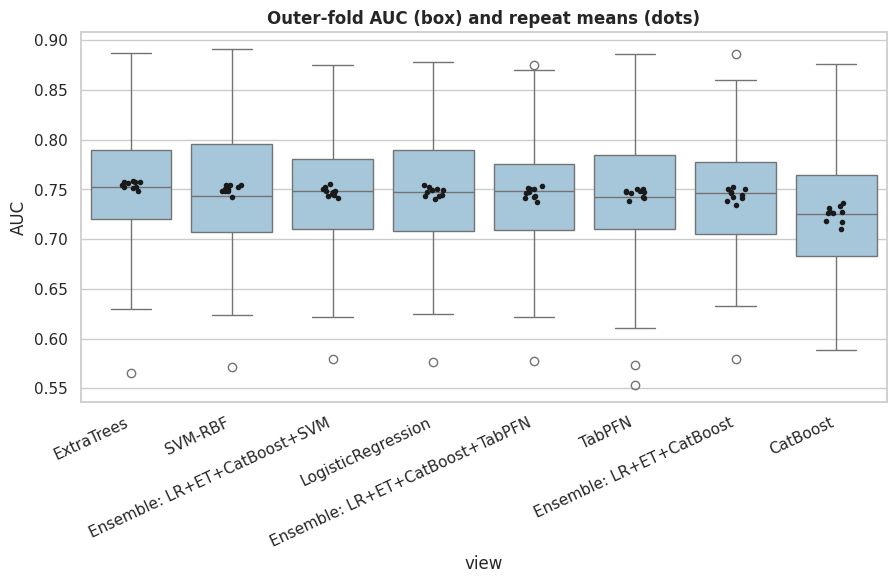

In [10]:
# ============================================================
# 7. Threshold-free results
# ============================================================
def corrected_ci(vals):
    v = np.asarray(vals, float); n = len(v); m = v.mean(); var = v.var(ddof=1)
    se = np.sqrt((1 / n + N_TE / N_TR) * var); tc = stats.t.ppf(0.975, n - 1)
    return m, se, m - tc * se, m + tc * se

def corrected_ttest(d):
    d = np.asarray(d, float); n = len(d); var = d.var(ddof=1)
    if var == 0:
        return 0.0, 1.0, 0.0
    se = np.sqrt((1 / n + N_TE / N_TR) * var); t_ = d.mean() / se
    return float(t_), float(2 * stats.t.sf(abs(t_), n - 1)), float(se)

def holm(pvals):
    p = np.asarray(pvals, float); n = len(p); adj = np.empty(n); running = 0.0
    for rank, idx in enumerate(np.argsort(p)):
        running = max(running, min(1.0, (n - rank) * p[idx])); adj[idx] = running
    return adj

base_rows = EVAL[EVAL["rule"] == "fixed_0.5"]
disc = []
for view in VIEWS:
    s = base_rows[base_rows["view"] == view]
    m, se, lo, hi = corrected_ci(s["AUC"])
    rep_means = s.groupby("repeat")["AUC"].mean()
    disc.append({"view": view, "AUC": m, "AUC_95CI": f"[{lo:.3f}, {hi:.3f}]", "AUC_fold_SD": s["AUC"].std(ddof=1),
                 "AUC_repeat_SD": rep_means.std(ddof=1) if len(rep_means) > 1 else np.nan,
                 "Brier": s["Brier"].mean(), "Brier_no_skill": PI_ALL * (1 - PI_ALL),
                 "Train_AUC": s["Train_AUC"].mean(), "Overfit_gap": s["Train_AUC"].mean() - m,
                 "fit_time_s": s["fit_time_s"].mean(), "predict_ms_per_1000": s["predict_ms_per_1000"].mean()})
DISC = pd.DataFrame(disc).set_index("view").sort_values("AUC", ascending=False)
display(DISC)

plt.figure(figsize=(max(8, 1.3 * len(VIEWS)), 4.8))
order = DISC.index.tolist()
sns.boxplot(data=base_rows, x="view", y="AUC", order=order, color="#9ecae1")
sns.stripplot(data=base_rows.groupby(["view", "repeat"], as_index=False)["AUC"].mean(), x="view", y="AUC",
              order=order, color="k", size=4)
plt.xticks(rotation=25, ha="right"); plt.title("Outer-fold AUC (box) and repeat means (dots)")
save_fig("auc_distribution"); plt.show()
EVIDENCE["discrimination"] = DISC[["AUC", "AUC_95CI", "Brier", "Overfit_gap", "AUC_repeat_SD"]].round(4).to_dict(orient="index")

## 8. Thresholded performance by rule (E3) and the majority-baseline test
Each cell below is the mean over 100 outer folds with a corrected 95% CI. The key question is answered directly: **does the model's accuracy beat predicting "disease" for everyone?** That is tested with a corrected paired t-test of the per-fold accuracy difference.

In [11]:
# ============================================================
# 8. Metrics per threshold rule
# ============================================================
KEY = ["Accuracy", "Balanced_Acc", "Recall_TPR", "TNR", "Precision", "F1", "MCC", "Kappa", "FPR", "FNR"]
def fmt_ci(vals):
    m, _, lo, hi = corrected_ci(vals)
    return f"{m:.3f} [{lo:.3f}, {hi:.3f}]"
rule_rows = []
for view in VIEWS:
    for rule, rlabel in RULES.items():
        s = EVAL[(EVAL["view"] == view) & (EVAL["rule"] == rule)]
        row = {"view": view, "rule": rlabel, "median_threshold": s["threshold"].median()}
        for mname in KEY:
            row[mname] = fmt_ci(s[mname])
        rule_rows.append(row)
RULE_TABLE = pd.DataFrame(rule_rows).set_index(["view", "rule"])
display(RULE_TABLE)
RULE_TABLE.to_csv(os.path.join(OUT_DIR, "metrics_by_threshold_rule.csv"))

base_tests = []
for view in VIEWS:
    s = EVAL[(EVAL["view"] == view) & (EVAL["rule"] == "accuracy")]
    d = s["Accuracy"].values - s["Majority_acc"].values
    t_, p_, se = corrected_ttest(d)
    s_b = EVAL[(EVAL["view"] == view) & (EVAL["rule"] == "balanced_accuracy")]["Balanced_Acc"].values
    t_b, p_b, _ = corrected_ttest(s_b - 0.5)
    base_tests.append({"view": view, "accuracy": s["Accuracy"].mean(), "majority_baseline": s["Majority_acc"].mean(),
                       "gain_vs_majority": d.mean(), "p_gain (corrected)": p_,
                       "balanced_acc": s_b.mean(), "p_BA>0.5 (corrected)": p_b})
BASELINE_TESTS = pd.DataFrame(base_tests).set_index("view")
display(BASELINE_TESTS)
EVIDENCE["accuracy_vs_majority"] = BASELINE_TESTS.round(4).to_dict(orient="index")

median_threshold              Accuracy          Balanced_Acc            Recall_TPR                   TNR             Precision                    F1                    MCC  \
view                            rule                                                                                                                                                                                                      
LogisticRegression              Accuracy-optimal                      0.2762  0.708 [0.682, 0.733]  0.554 [0.507, 0.601]  0.915 [0.836, 0.995]  0.193 [0.033, 0.353]  0.744 [0.712, 0.776]  0.814 [0.787, 0.841]   0.131 [0.028, 0.233]   
                                Balanced-accuracy-optimal             0.5000  0.661 [0.612, 0.710]  0.697 [0.652, 0.742]  0.612 [0.535, 0.688]  0.782 [0.690, 0.874]  0.870 [0.799, 0.941]  0.714 [0.647, 0.780]   0.361 [0.281, 0.441]   
                                Sensitivity >= 0.90                   0.3400  0.707 [0.675, 0.740]  0.587 [0.528, 0.647]  0.869 [0.793, 0.945]  0.306 [0.133, 0.478]  0.763 [0.727, 0.800]  0.807 [0.778, 0.835]   0.181 [0.056, 0.307]   
                                Fixed 0.5 (balanced scale)            0.5000  0.663 [0.625, 0.701]  0.703 [0.664, 0.742]  0.608 [0.558, 0.659]  0.797 [0.727, 0.868]  0.884 [0.849, 0.919]  0.718 [0.679, 0.756]   0.370 [0.299, 0.442]   
ExtraTrees                      Accuracy-optimal                      0.3150  0.706 [0.682, 0.729]  0.551 [0.512, 0.589]  0.916 [0.860, 0.973]  0.185 [0.070, 0.300]  0.738 [0.716, 0.761]  0.815 [0.795, 0.835]   0.134 [0.042, 0.227]   
                                Balanced-accuracy-optimal             0.5300  0.652 [0.611, 0.692]  0.695 [0.653, 0.736]  0.593 [0.537, 0.649]  0.796 [0.720, 0.872]  0.882 [0.844, 0.920]  0.705 [0.663, 0.748]   0.356 [0.281, 0.431]   
                                Sensitivity >= 0.90                   0.3350  0.713 [0.684, 0.742]  0.570 [0.536, 0.604]  0.906 [0.872, 0.941]  0.234 [0.170, 0.298]  0.746 [0.729, 0.763]  0.818 [0.798, 0.837]   0.191 [0.097, 0.284]   
                                Fixed 0.5 (balanced scale)            0.5000  0.670 [0.633, 0.707]  0.699 [0.659, 0.739]  0.630 [0.583, 0.678]  0.768 [0.697, 0.838]  0.873 [0.839, 0.907]  0.729 [0.694, 0.765]   0.363 [0.291, 0.435]   
CatBoost                        Accuracy-optimal                      0.2050  0.705 [0.686, 0.724]  0.514 [0.493, 0.535]  0.965 [0.932, 0.997]  0.063 [0.012, 0.115]  0.719 [0.708, 0.729]  0.823 [0.809, 0.837]  0.057 [-0.024, 0.139]   
                                Balanced-accuracy-optimal             0.6650  0.611 [0.567, 0.655]  0.676 [0.631, 0.721]  0.522 [0.460, 0.585]  0.830 [0.746, 0.913]  0.889 [0.844, 0.934]  0.652 [0.600, 0.704]   0.327 [0.245, 0.408]   
                                Sensitivity >= 0.90                   0.2888  0.704 [0.677, 0.731]  0.555 [0.524, 0.585]  0.906 [0.872, 0.940]  0.203 [0.145, 0.262]  0.738 [0.723, 0.754]  0.813 [0.794, 0.832]   0.153 [0.067, 0.238]   
                                Fixed 0.5 (balanced scale)            0.5000  0.662 [0.620, 0.703]  0.666 [0.617, 0.714]  0.656 [0.609, 0.704]  0.675 [0.591, 0.759]  0.835 [0.797, 0.873]  0.733 [0.697, 0.770]   0.304 [0.216, 0.393]   
SVM-RBF                         Accuracy-optimal                      0.5150  0.688 [0.660, 0.717]  0.548 [0.509, 0.588]  0.879 [0.816, 0.942]  0.217 [0.099, 0.336]  0.738 [0.715, 0.761]  0.799 [0.775, 0.823]   0.112 [0.021, 0.204]   
                                Balanced-accuracy-optimal             0.6950  0.679 [0.639, 0.719]  0.715 [0.675, 0.755]  0.630 [0.580, 0.680]  0.800 [0.737, 0.862]  0.887 [0.855, 0.920]  0.735 [0.695, 0.774]   0.392 [0.319, 0.465]   
                                Sensitivity >= 0.90                   0.4800  0.704 [0.674, 0.735]  0.556 [0.519, 0.593]  0.905 [0.872, 0.938]  0.207 [0.139, 0.276]  0.739 [0.720, 0.758]  0.813 [0.792, 0.834]   0.154 [0.057, 0.251]   
                                Fixed 0.5 (balanced scale)       

,accuracy,majority_baseline,gain_vs_majority,p_gain (corrected),balanced_acc,p_BA>0.5 (corrected)
view,,,,,,
LogisticRegression,0.7077,0.7123,-0.0046,0.7186,0.6970,0.0000
ExtraTrees,0.7056,0.7123,-0.0067,0.5935,0.6945,0.0000
CatBoost,0.7053,0.7123,-0.0070,0.4584,0.6760,0.0000
SVM-RBF,0.6884,0.7123,-0.0239,0.0953,0.7150,0.0000
TabPFN,0.7049,0.7123,-0.0074,0.4900,0.6952,0.0000
Ensemble: LR+ET+CatBoost,0.7065,0.7123,-0.0058,0.5643,0.6876,0.0000
Ensemble: LR+ET+CatBoost+SVM,0.7035,0.7123,-0.0088,0.5417,0.6943,0.0000
Ensemble: LR+ET+CatBoost+TabPFN,0.7026,0.7123,-0.0096,0.4110,0.6882,0.0000


## 9. Ensemble ablation and TabPFN (E4, E5) → final model
Each add-on is compared with the core ensemble on the same 100 outer folds. An add-on is adopted only if its mean AUC gain exceeds one **corrected** standard error. Rank averaging is also tested, to check that the ensemble does not depend on probability scale.

Choosing among at most three candidate ensembles on the folds that also report them adds a small selection optimism. The core ensemble is pre-specified, so its estimate carries none.

In [12]:
# ============================================================
# 9. Ablations -> FINAL_VIEW
# ============================================================
auc_f = base_rows.pivot_table(index=["repeat", "fold"], columns="view", values="AUC")
abl = []
FINAL_VIEW, best_gain = CORE_VIEW, 0.0
for view in VIEWS:
    if view == CORE_VIEW:
        continue
    d = (auc_f[view] - auc_f[CORE_VIEW]).values
    t_, p_, se = corrected_ttest(d)
    adopt = view.startswith("Ensemble") and d.mean() > se
    abl.append({"comparison": f"{view} vs {CORE_VIEW}", "mean_dAUC": d.mean(), "corrected_SE": se, "p_corrected": p_,
                "adopt_as_final": adopt})
    if adopt and d.mean() > best_gain:
        FINAL_VIEW, best_gain = view, d.mean()

# rank averaging of the core members (AUC only; ranks have no probability scale)
rank_auc = []
for f, (r, k, tr, va) in enumerate(OUTER):
    ranks = np.mean([rankdata(RES[m][f]["p_va"]) / len(va) for m in CORE], axis=0)
    rank_auc.append(roc_auc_score(y[va], ranks))
d = np.asarray(rank_auc) - auc_f[CORE_VIEW].values
t_, p_, se = corrected_ttest(d)
abl.append({"comparison": f"Rank-average vs probability-average ({CORE_VIEW})", "mean_dAUC": d.mean(),
            "corrected_SE": se, "p_corrected": p_, "adopt_as_final": False})
if "TabPFN" in MODELS:
    d = (auc_f["TabPFN"] - auc_f["LogisticRegression"]).values
    t_, p_, se = corrected_ttest(d)
    abl.append({"comparison": "TabPFN alone vs LR alone", "mean_dAUC": d.mean(), "corrected_SE": se,
                "p_corrected": p_, "adopt_as_final": False})
ABLATION = pd.DataFrame(abl)
display(ABLATION)
FINAL_MEMBERS = VIEWS[FINAL_VIEW]
print(f">>> FINAL MODEL: {FINAL_VIEW}  (members: {FINAL_MEMBERS})")
EVIDENCE["final_model"] = {"view": FINAL_VIEW, "members": FINAL_MEMBERS,
                           "ablation": ABLATION.round(4).to_dict(orient="records")}

,comparison,mean_dAUC,corrected_SE,p_corrected,adopt_as_final
0,LogisticRegression vs Ensemble: LR+ET+CatBoost,0.0028,0.0105,0.7909,False
1,ExtraTrees vs Ensemble: LR+ET+CatBoost,0.0098,0.0075,0.1897,False
2,CatBoost vs Ensemble: LR+ET+CatBoost,-0.0193,0.0093,0.0398,False
3,SVM-RBF vs Ensemble: LR+ET+CatBoost,0.0058,0.0119,0.6276,False
4,TabPFN vs Ensemble: LR+ET+CatBoost,0.0014,0.0095,0.8811,False
5,Ensemble: LR+ET+CatBoost+SVM vs Ensemble: LR+E...,0.0030,0.0042,0.4743,False
6,Ensemble: LR+ET+CatBoost+TabPFN vs Ensemble: L...,0.0016,0.0028,0.5657,False
7,Rank-average vs probability-average (Ensemble:...,0.0041,0.0034,0.2256,False
8,TabPFN alone vs LR alone,-0.0014,0.0070,0.8436,False


>>> FINAL MODEL: Ensemble: LR+ET+CatBoost  (members: ['LogisticRegression', 'ExtraTrees', 'CatBoost'])


## 10. Visual evaluation (out-of-fold predictions only)
- **ROC, calibration and decision curves** use each patient's out-of-fold probability averaged over the 10 repeats (calibrated per fold with the training prevalence).
- **Confusion matrices** add up all 100 outer folds, each at its own nested threshold, and are divided by the number of repeats. The counts are therefore "per full pass over the 570 patients", and every threshold was chosen without seeing the fold being scored.

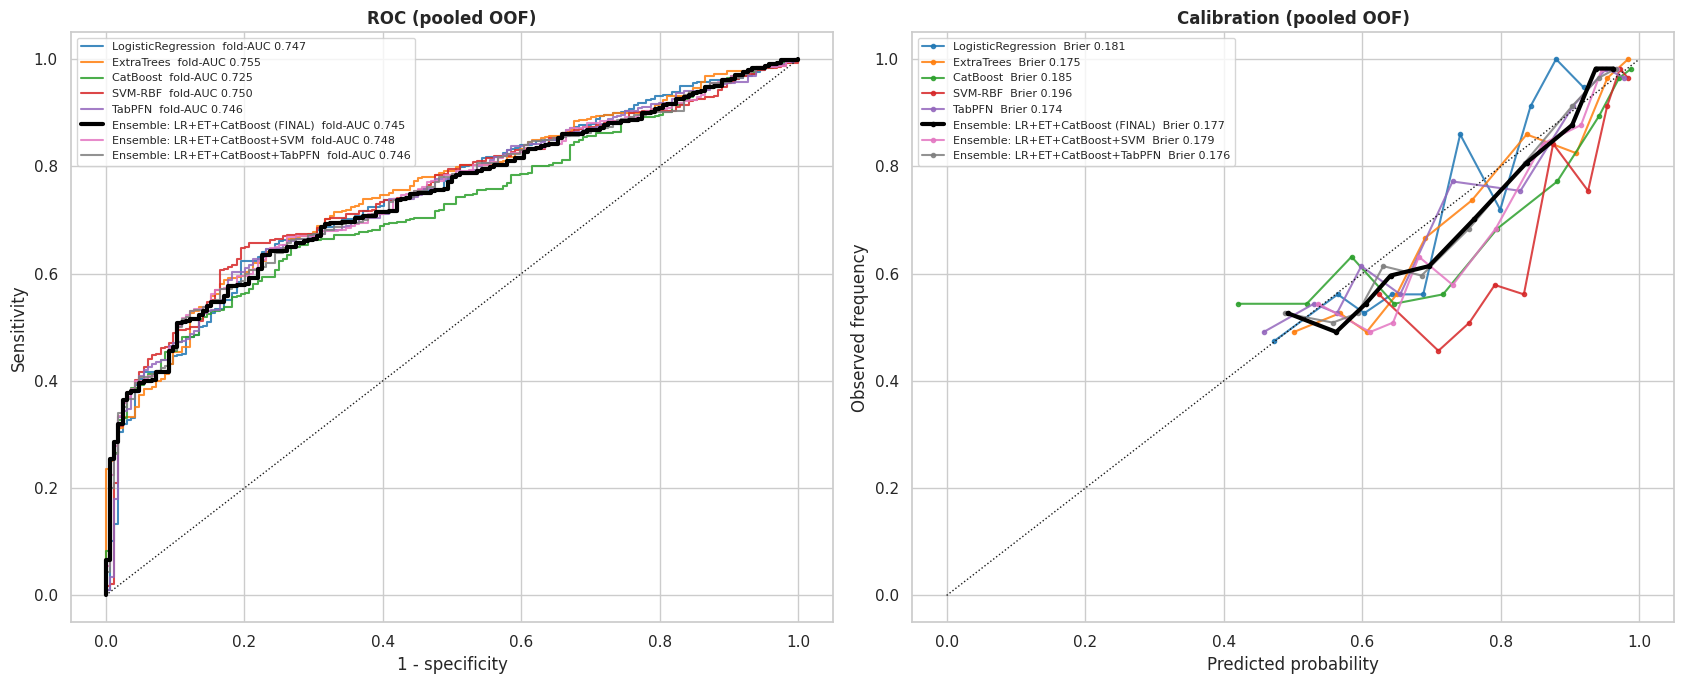

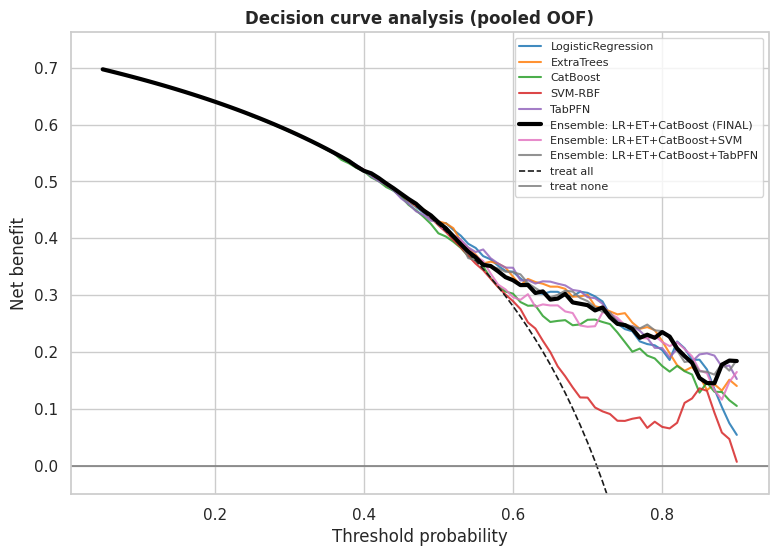

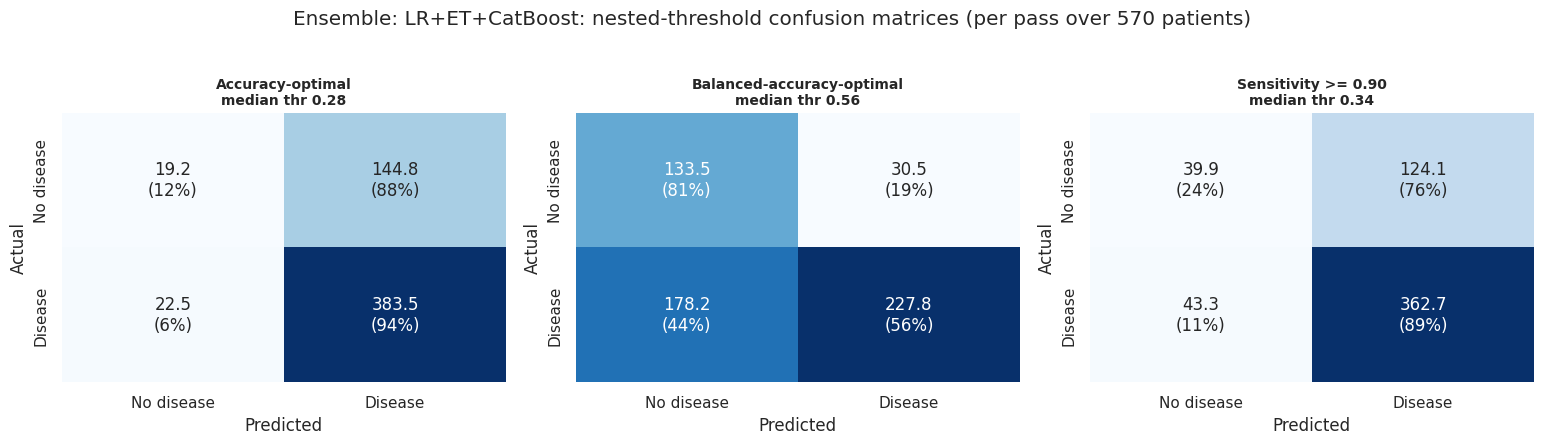

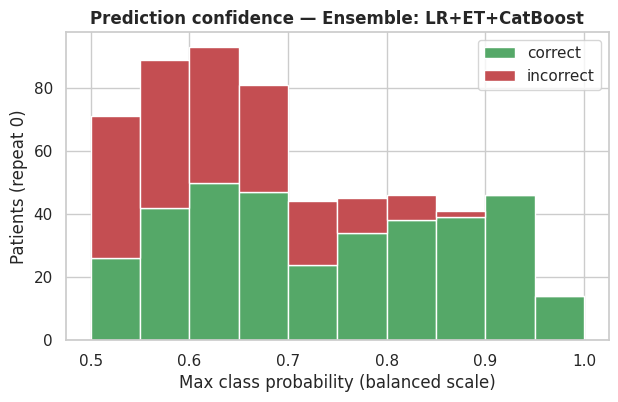

In [13]:
# ============================================================
# 10. Visualisations
# ============================================================
def pooled_oof(members, calibrated=True):
    acc = np.zeros(N)
    for f, (r, k, tr, va) in enumerate(OUTER):
        p = combo(members, f, "p_va")
        acc[va] += shift_prior(p, 0.5, float(y[tr].mean())) if calibrated else p
    return acc / N_REPEATS

OOF_CAL = OrderedDict((v, pooled_oof(m, True)) for v, m in VIEWS.items())
OOF_BAL = OrderedDict((v, pooled_oof(m, False)) for v, m in VIEWS.items())
COLORS = dict(zip(VIEWS, sns.color_palette("tab10", len(VIEWS))))
def style(v):
    return dict(color="black", lw=3, zorder=10) if v == FINAL_VIEW else dict(color=COLORS[v], lw=1.5, alpha=0.85)
def label(v):
    return f"{v} (FINAL)" if v == FINAL_VIEW else v

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
for v in VIEWS:
    fpr_, tpr_, _ = roc_curve(y, OOF_CAL[v])
    axes[0].plot(fpr_, tpr_, label=f"{label(v)}  fold-AUC {DISC.loc[v, 'AUC']:.3f}", **style(v))
    fp_, mp_ = calibration_curve(y, OOF_CAL[v], n_bins=10, strategy="quantile")
    axes[1].plot(mp_, fp_, marker="o", ms=3, label=f"{label(v)}  Brier {DISC.loc[v, 'Brier']:.3f}", **style(v))
for ax in axes:
    ax.plot([0, 1], [0, 1], "k:", lw=1); ax.legend(fontsize=8)
axes[0].set_xlabel("1 - specificity"); axes[0].set_ylabel("Sensitivity"); axes[0].set_title("ROC (pooled OOF)")
axes[1].set_xlabel("Predicted probability"); axes[1].set_ylabel("Observed frequency"); axes[1].set_title("Calibration (pooled OOF)")
plt.tight_layout(); save_fig("roc_calibration"); plt.show()

def net_benefit(yy, p, ths):
    n = len(yy)
    return np.array([np.sum((p >= t_) & (yy == 1)) / n - np.sum((p >= t_) & (yy == 0)) / n * t_ / (1 - t_) for t_ in ths])
TH = np.linspace(0.05, 0.90, 86)
plt.figure(figsize=(9, 6))
for v in VIEWS:
    plt.plot(TH, net_benefit(y, OOF_CAL[v], TH), label=label(v), **style(v))
plt.plot(TH, PI_ALL - (1 - PI_ALL) * TH / (1 - TH), "k--", lw=1.2, label="treat all")
plt.axhline(0, color="grey", lw=1.2, label="treat none")
plt.ylim(-0.05, PI_ALL + 0.05); plt.xlabel("Threshold probability"); plt.ylabel("Net benefit")
plt.title("Decision curve analysis (pooled OOF)"); plt.legend(fontsize=8); save_fig("decision_curves"); plt.show()

fig, axes = plt.subplots(1, len(RULES) - 1, figsize=(5.2 * (len(RULES) - 1), 4.3))
for ax, rule in zip(axes, [r_ for r_ in RULES if r_ != "fixed_0.5"]):
    s = EVAL[(EVAL["view"] == FINAL_VIEW) & (EVAL["rule"] == rule)]
    cm = np.array([[s["TN"].sum(), s["FP"].sum()], [s["FN"].sum(), s["TP"].sum()]]) / N_REPEATS
    annot = np.array([[f"{cm[i, j]:.1f}\n({cm[i, j] / cm[i].sum():.0%})" for j in range(2)] for i in range(2)])
    sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["No disease", "Disease"], yticklabels=["No disease", "Disease"])
    ax.set_title(f"{RULES[rule]}\nmedian thr {s['threshold'].median():.2f}", fontsize=10)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.suptitle(f"{FINAL_VIEW}: nested-threshold confusion matrices (per pass over {N} patients)", y=1.03)
plt.tight_layout(); save_fig("confusion_by_rule"); plt.show()

p0 = PROB0[FINAL_VIEW]; pr0 = PRED0[FINAL_VIEW]["balanced_accuracy"]
conf = np.maximum(p0, 1 - p0); correct = pr0 == y
plt.figure(figsize=(7, 4))
plt.hist([conf[correct], conf[~correct]], bins=np.linspace(0.5, 1, 11), stacked=True,
         color=["#55A868", "#C44E52"], label=["correct", "incorrect"])
plt.xlabel("Max class probability (balanced scale)"); plt.ylabel("Patients (repeat 0)")
plt.title(f"Prediction confidence — {FINAL_VIEW}"); plt.legend(); save_fig("confidence_hist"); plt.show()

## 11. Statistical significance
- **AUC:** paired comparisons over the same 100 outer folds, using the standard paired t-test and the corrected repeated-CV t-test (Nadeau & Bengio; Bouckaert & Frank), with Holm adjustment.
- **Bowker symmetry**, on the repeat-0 out-of-fold predictions at the balanced-accuracy rule: (a) whether each model's FN and FP counts are asymmetric (a 2×2 table, where Bowker equals McNemar; an exact binomial p is also shown); (b) the final model against each other model, using a 3×3 table of patient outcomes (correct / FP / FN).

In [14]:
# ============================================================
# 11. Statistical tests
# ============================================================
rows = []
for v in VIEWS:
    if v == FINAL_VIEW:
        continue
    a, b = auc_f[FINAL_VIEW].values, auc_f[v].values
    t_c, p_c, _ = corrected_ttest(a - b)
    rows.append({"comparison": f"{FINAL_VIEW} vs {v}", "mean_dAUC": (a - b).mean(),
                 "p_paired_t": stats.ttest_rel(a, b).pvalue if np.any(a != b) else 1.0, "p_corrected": p_c})
TTESTS = pd.DataFrame(rows)
if len(TTESTS):
    TTESTS["p_corrected_Holm"] = holm(TTESTS["p_corrected"].values)
display(TTESTS)

def bowker_test(table):
    t_ = np.asarray(table, float); stat, dof = 0.0, 0
    for i in range(t_.shape[0]):
        for j in range(i + 1, t_.shape[0]):
            s = t_[i, j] + t_[j, i]
            if s > 0:
                stat += (t_[i, j] - t_[j, i]) ** 2 / s; dof += 1
    return stat, dof, (stats.chi2.sf(stat, dof) if dof else 1.0)

brow = []
for v in VIEWS:
    pr = PRED0[v]["balanced_accuracy"]
    fp, fn = int(np.sum((pr == 1) & (y == 0))), int(np.sum((pr == 0) & (y == 1)))
    stat, dof, p = bowker_test([[0, fp], [fn, 0]])
    brow.append({"view": v, "FP": fp, "FN": fn, "Bowker_chi2": stat, "p": p,
                 "p_exact_binomial": stats.binomtest(min(fp, fn), fp + fn, 0.5).pvalue if fp + fn else 1.0})
BOWKER_ERRORS = pd.DataFrame(brow).set_index("view")
display(BOWKER_ERRORS)

def outcome_codes(yy, pred):
    return np.where(pred == yy, 0, np.where(pred == 1, 1, 2))
c_final = outcome_codes(y, PRED0[FINAL_VIEW]["balanced_accuracy"])
prow = []
for v in VIEWS:
    if v == FINAL_VIEW:
        continue
    tab = np.zeros((3, 3))
    np.add.at(tab, (c_final, outcome_codes(y, PRED0[v]["balanced_accuracy"])), 1)
    stat, dof, p = bowker_test(tab)
    prow.append({"comparison": f"{FINAL_VIEW} vs {v}", "Bowker_chi2": stat, "df": dof, "p": p,
                 "final_only_correct": int(tab[0, 1:].sum()), "other_only_correct": int(tab[1:, 0].sum())})
BOWKER_PAIRS = pd.DataFrame(prow)
display(BOWKER_PAIRS)

,comparison,mean_dAUC,p_paired_t,p_corrected,p_corrected_Holm
0,Ensemble: LR+ET+CatBoost vs LogisticRegression,-0.0028,0.3572,0.7909,1.0000
1,Ensemble: LR+ET+CatBoost vs ExtraTrees,-0.0098,0.0000,0.1897,1.0000
2,Ensemble: LR+ET+CatBoost vs CatBoost,0.0193,0.0000,0.0398,0.2786
3,Ensemble: LR+ET+CatBoost vs SVM-RBF,-0.0058,0.0935,0.6276,1.0000
4,Ensemble: LR+ET+CatBoost vs TabPFN,-0.0014,0.6029,0.8811,1.0000
5,Ensemble: LR+ET+CatBoost vs Ensemble: LR+ET+Ca...,-0.0030,0.0141,0.4743,1.0000
6,Ensemble: LR+ET+CatBoost vs Ensemble: LR+ET+Ca...,-0.0016,0.0476,0.5657,1.0000


,FP,FN,Bowker_chi2,p,p_exact_binomial
view,,,,,
LogisticRegression,34,158,80.0833,0.0000,0.0000
ExtraTrees,32,170,94.2772,0.0000,0.0000
CatBoost,29,200,127.6900,0.0000,0.0000
SVM-RBF,32,149,75.6298,0.0000,0.0000
TabPFN,33,161,84.4536,0.0000,0.0000
Ensemble: LR+ET+CatBoost,32,178,101.5048,0.0000,0.0000
Ensemble: LR+ET+CatBoost+SVM,33,171,93.3529,0.0000,0.0000
Ensemble: LR+ET+CatBoost+TabPFN,33,178,99.6445,0.0000,0.0000


,comparison,Bowker_chi2,df,p,final_only_correct,other_only_correct
0,Ensemble: LR+ET+CatBoost vs LogisticRegression,12.8333,2,0.0016,13,31
1,Ensemble: LR+ET+CatBoost vs ExtraTrees,2.4615,2,0.2921,12,20
2,Ensemble: LR+ET+CatBoost vs CatBoost,20.8590,2,0.0000,28,9
3,Ensemble: LR+ET+CatBoost vs SVM-RBF,22.7297,2,0.0000,10,39
4,Ensemble: LR+ET+CatBoost vs TabPFN,10.8148,2,0.0045,10,26
5,Ensemble: LR+ET+CatBoost vs Ensemble: LR+ET+Ca...,4.7879,2,0.0913,4,10
6,Ensemble: LR+ET+CatBoost vs Ensemble: LR+ET+Ca...,1.0000,2,0.6065,6,5


## 12. Efficiency and model complexity
Times are per outer fit (about 513 patients), and prediction time is per 1,000 patients. Serialized size and complexity (learned parameters or tree nodes) come from the members of the final model fitted on all data in Section 16.

In [15]:
# ============================================================
# 12. Efficiency (timings from the engine)
# ============================================================
display(DISC[["fit_time_s", "predict_ms_per_1000"]].sort_values("fit_time_s"))

,fit_time_s,predict_ms_per_1000
view,,
SVM-RBF,0.1425,153.6483
TabPFN,0.1949,"4,820.9244"
LogisticRegression,0.4955,118.8578
CatBoost,0.5076,110.6020
ExtraTrees,1.1349,"1,197.3717"
Ensemble: LR+ET+CatBoost,2.1379,"1,426.8314"
Ensemble: LR+ET+CatBoost+SVM,2.2804,"1,580.4798"
Ensemble: LR+ET+CatBoost+TabPFN,2.3328,"6,247.7559"


## 13. Risk–coverage: selective prediction (E6)
Patients are ranked by the confidence of the calibrated out-of-fold prediction, max(p, 1 − p). Accuracy is then computed on the most confident fraction (the coverage). The coverage cut-off is a quantile of predicted confidence and uses no labels.

This is the only honest route to a 90%+ accuracy figure on ILPD, and it **must be reported together with its coverage**. The composition columns show which kind of patient drives that accuracy.

For deployment, the coverage is converted into a fixed **confidence cut-off** (a quantile of the out-of-fold confidences). `predict_new()` in Section 16 then flags patients below it as "refer / no automated decision".

,accuracy,accuracy_sd,share_predicted_disease,disease_prevalence_covered
coverage,,,,
0.1000,0.9860,0.0074,1.0000,0.9860
0.1500,0.9791,0.0049,1.0000,0.9791
0.2000,0.9781,0.0095,1.0000,0.9781
0.2500,0.9627,0.0100,1.0000,0.9627
0.3000,0.9415,0.0068,1.0000,0.9415
0.3500,0.9200,0.0047,1.0000,0.9200
0.4000,0.9118,0.0048,1.0000,0.9118
0.4500,0.8914,0.0061,1.0000,0.8914
0.5000,0.8702,0.0044,1.0000,0.8702


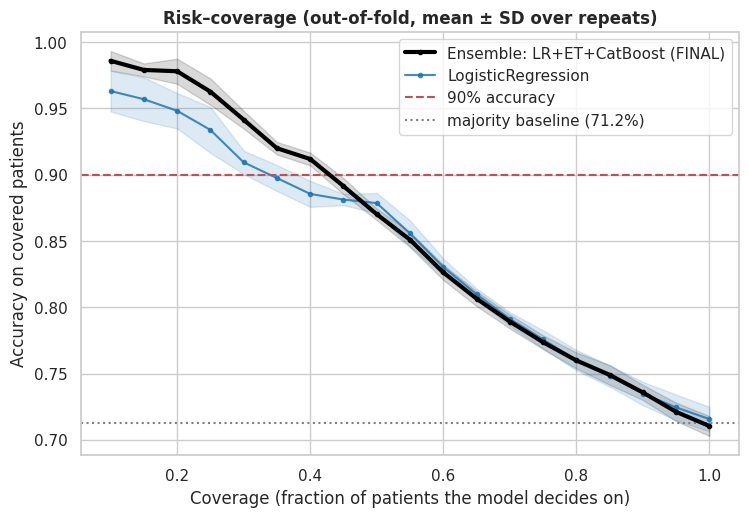

Largest coverage with mean OOF accuracy >= 90%: 40%
  at that coverage: 100% of covered patients are predicted diseased; disease prevalence among them 91% (vs 71% overall)
  deployment confidence cut-off for that coverage: max(p, 1-p) >= 0.793 (calibrated scale)


In [16]:
# ============================================================
# 13. Risk-coverage curves
# ============================================================
COVERAGES = np.round(np.linspace(0.10, 1.00, 19), 2)
def repeat_oof(members, r):
    arr = np.full(N, np.nan)
    for f, (rr, k, tr, va) in enumerate(OUTER):
        if rr == r:
            arr[va] = shift_prior(combo(members, f, "p_va"), 0.5, float(y[tr].mean()))
    return arr

def risk_coverage(members):
    rows = []
    for r in range(N_REPEATS):
        p = repeat_oof(members, r); pred = (p >= 0.5).astype(int); conf = np.maximum(p, 1 - p)
        order = np.argsort(-conf, kind="stable")
        for c in COVERAGES:
            idx = order[: max(1, int(round(c * N)))]
            rows.append({"repeat": r, "coverage": c, "accuracy": np.mean(pred[idx] == y[idx]),
                         "share_predicted_disease": pred[idx].mean(), "disease_prevalence_covered": y[idx].mean()})
    return pd.DataFrame(rows).groupby("coverage").agg(accuracy=("accuracy", "mean"), accuracy_sd=("accuracy", "std"),
                                                       share_predicted_disease=("share_predicted_disease", "mean"),
                                                       disease_prevalence_covered=("disease_prevalence_covered", "mean"))

RC = OrderedDict((v, risk_coverage(VIEWS[v])) for v in [FINAL_VIEW, "LogisticRegression"] if v in VIEWS)
display(RC[FINAL_VIEW])
plt.figure(figsize=(8.5, 5.5))
for v, tab in RC.items():
    plt.plot(tab.index, tab["accuracy"], marker="o", ms=3, label=label(v), **style(v))
    plt.fill_between(tab.index, tab["accuracy"] - tab["accuracy_sd"], tab["accuracy"] + tab["accuracy_sd"],
                     alpha=0.15, color="black" if v == FINAL_VIEW else COLORS[v])
plt.axhline(0.90, ls="--", c="#C44E52", label="90% accuracy")
plt.axhline(PI_ALL, ls=":", c="grey", label=f"majority baseline ({PI_ALL:.1%})")
plt.xlabel("Coverage (fraction of patients the model decides on)"); plt.ylabel("Accuracy on covered patients")
plt.title("Risk–coverage (out-of-fold, mean ± SD over repeats)"); plt.legend(); save_fig("risk_coverage"); plt.show()

tab = RC[FINAL_VIEW]
reach = tab[tab["accuracy"] >= 0.90]
COV90 = float(reach.index.max()) if len(reach) else 0.0
print(f"Largest coverage with mean OOF accuracy >= 90%: {COV90:.0%}" if COV90 else
      "No coverage level reached 90% mean accuracy.")
if COV90:
    rr = tab.loc[COV90]
    print(f"  at that coverage: {rr['share_predicted_disease']:.0%} of covered patients are predicted diseased; "
          f"disease prevalence among them {rr['disease_prevalence_covered']:.0%} (vs {PI_ALL:.0%} overall)")
_conf_oof = np.maximum(OOF_CAL[FINAL_VIEW], 1 - OOF_CAL[FINAL_VIEW])
CONF_CUT90 = float(np.quantile(_conf_oof, 1 - COV90)) if COV90 else None
if CONF_CUT90 is not None:
    print(f"  deployment confidence cut-off for that coverage: max(p, 1-p) >= {CONF_CUT90:.3f} (calibrated scale)")
EVIDENCE["risk_coverage"] = {"coverage_at_90pct": COV90, "confidence_cutoff": CONF_CUT90,
                             "table": tab.round(4).reset_index().to_dict(orient="records")}

## 14. Learning curve (E1) — is the problem data-limited?
The training folds are subsampled to 25–100% (5-fold × 4 repeats), always scoring on the untouched validation fold.
- **A flat curve near 100%** means more patients of the same kind would not help. The ceiling is then the information in the features and labels.
- **A still-rising curve** means more data would help.

The dashed lines (training AUC) show how the overfitting gap shrinks as n grows.

,model,frac,n_train,val_auc,val_se,train_auc
0,CatBoost,0.2500,114.0000,0.6978,0.0096,1.0000
1,CatBoost,0.4000,182.0000,0.7098,0.0105,0.9995
2,CatBoost,0.5500,250.0000,0.7228,0.0115,0.9973
3,CatBoost,0.7000,319.0000,0.7227,0.0106,0.9925
4,CatBoost,0.8500,387.0000,0.7214,0.0112,0.9867
5,CatBoost,1.0000,456.0000,0.7229,0.0102,0.9794
6,ExtraTrees,0.2500,114.0000,0.7197,0.0082,0.9545
7,ExtraTrees,0.4000,182.0000,0.7284,0.0103,0.9605
8,ExtraTrees,0.5500,250.0000,0.7445,0.0098,0.9628
9,ExtraTrees,0.7000,319.0000,0.7394,0.0094,0.9632


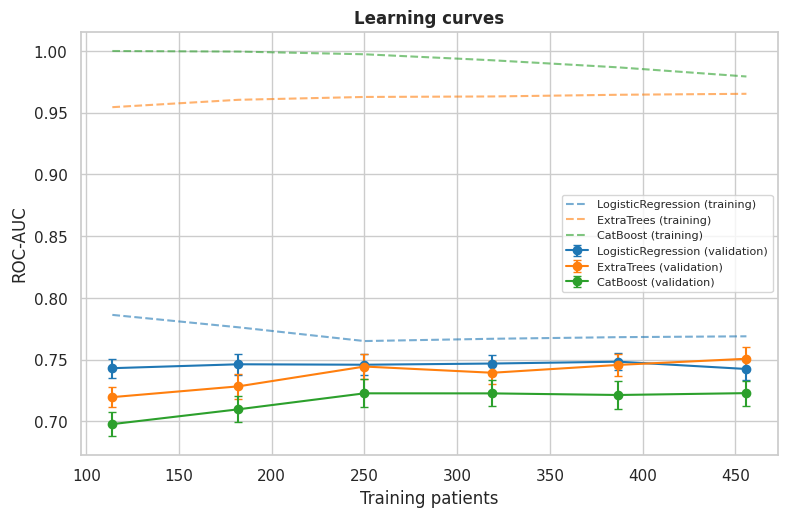

LogisticRegression   AUC gain 70%->100% of training data: -0.0044 (±0.0114) -> plateau (data-limited)
ExtraTrees           AUC gain 70%->100% of training data: +0.0113 (±0.0132) -> plateau (data-limited)
CatBoost             AUC gain 70%->100% of training data: +0.0002 (±0.0147) -> plateau (data-limited)


In [17]:
# ============================================================
# 14. Learning curve
# ============================================================
LC_CV = list(RepeatedStratifiedKFold(n_splits=5, n_repeats=LC_REPEATS, random_state=SEED + 100).split(X, y))
def _lc_task(name, frac, i, tr, va, X, y):
    seed = SEED + i
    sub = tr if frac >= 1 else train_test_split(tr, train_size=frac, stratify=y[tr], random_state=seed)[0]
    pipe = build_member(name, seed).fit(X.iloc[sub], y[sub])
    return {"model": name, "frac": frac, "n_train": len(sub),
            "val_auc": roc_auc_score(y[va], pipe.predict_proba(X.iloc[va])[:, 1]),
            "train_auc": roc_auc_score(y[sub], pipe.predict_proba(X.iloc[sub])[:, 1])}
LC = pd.DataFrame(Parallel(n_jobs=N_JOBS)(delayed(_lc_task)(m, fr, i, tr, va, X, y)
                                          for m in CORE for fr in LC_FRACTIONS for i, (tr, va) in enumerate(LC_CV)))
LC_SUM = LC.groupby(["model", "frac"]).agg(n_train=("n_train", "mean"), val_auc=("val_auc", "mean"),
                                            val_se=("val_auc", lambda s: s.std(ddof=1) / np.sqrt(len(s))),
                                            train_auc=("train_auc", "mean")).reset_index()
display(LC_SUM)
plt.figure(figsize=(9, 5.5))
for i, m in enumerate(CORE):
    s = LC_SUM[LC_SUM["model"] == m]; col = sns.color_palette("tab10")[i]
    plt.errorbar(s["n_train"], s["val_auc"], yerr=s["val_se"], marker="o", capsize=3, color=col, label=f"{m} (validation)")
    plt.plot(s["n_train"], s["train_auc"], ls="--", color=col, alpha=0.6, label=f"{m} (training)")
plt.xlabel("Training patients"); plt.ylabel("ROC-AUC"); plt.title("Learning curves")
plt.legend(fontsize=8); save_fig("learning_curves"); plt.show()

lc_verdict = {}
for m in CORE:
    s = LC[LC["model"] == m]
    a70 = s[np.isclose(s["frac"], 0.7)]["val_auc"].values; a100 = s[np.isclose(s["frac"], 1.0)]["val_auc"].values
    gain = a100.mean() - a70.mean(); se = np.sqrt(a70.var(ddof=1) / len(a70) + a100.var(ddof=1) / len(a100))
    lc_verdict[m] = {"gain_70_to_100pct": round(float(gain), 4), "approx_SE": round(float(se), 4),
                     "verdict": "plateau (data-limited)" if gain < max(0.01, 2 * se) else "still improving (more data would help)"}
    print(f"{m:<20} AUC gain 70%->100% of training data: {gain:+.4f} (±{se:.4f}) -> {lc_verdict[m]['verdict']}")
EVIDENCE["learning_curve"] = lc_verdict

## 15. Label-noise audit (E7) and parsimony check (E8)
**E7.**
- First the descriptive step: patients whose calibrated out-of-fold probability strongly contradicts their label (no-disease label with P ≥ 0.90, or disease label with P ≤ 0.25).
- Then the experiment: inside each outer training fold only, remove the patients flagged **by that fold's inner out-of-fold predictions**, refit the final model, and score the untouched validation fold.
- The validation labels stay as recorded, so this measures whether noisy *training* labels hurt the model.

**E8.** Refit the final model without Gender and Total protein, the two inputs with no significant univariate association in the audit (Total protein AUC 0.52, p = 0.44; Gender χ² p = 0.06), to test whether the simpler model loses anything.

In [18]:
# ============================================================
# 15. Label-noise audit + parsimony
# ============================================================
p_oof = OOF_CAL[FINAL_VIEW]
suspect = ((y == 0) & (p_oof >= NOISE_HIGH)) | ((y == 1) & (p_oof <= NOISE_LOW))
print(f"Suspicious labels (pooled OOF): {suspect.sum()} of {N} "
      f"({((y == 0) & (p_oof >= NOISE_HIGH)).sum()} 'no disease' with P>={NOISE_HIGH}, "
      f"{((y == 1) & (p_oof <= NOISE_LOW)).sum()} 'disease' with P<={NOISE_LOW})")
display(df.loc[suspect, FEATURES + ["Target"]].assign(OOF_P_disease=p_oof[suspect]).sort_values("OOF_P_disease"))

def _refit_eval(members, seed, Xtr, ytr, Xva):
    return np.mean([build_member(m, seed).fit(Xtr, ytr).predict_proba(Xva)[:, 1] for m in members], axis=0)

def _noise_task(f, r, tr, va, inner_cal, X, y, members):
    ytr = y[tr]
    flag = ((ytr == 0) & (inner_cal >= NOISE_HIGH)) | ((ytr == 1) & (inner_cal <= NOISE_LOW))
    keep = tr[~flag]
    p = _refit_eval(members, SEED + r, X.iloc[keep], y[keep], X.iloc[va])
    return {"f": f, "n_removed": int(flag.sum()), "auc": roc_auc_score(y[va], p)}

def _subset_task(f, r, tr, va, X, y, members, feats):
    p = _refit_eval(members, SEED + r, X.iloc[tr][feats], y[tr], X.iloc[va][feats])
    return {"f": f, "auc": roc_auc_score(y[va], p)}

jobs = 1 if "TabPFN" in FINAL_MEMBERS else N_JOBS
sel = [(f, o) for f, o in enumerate(OUTER) if o[0] < NOISE_REPEATS]
noise = pd.DataFrame(Parallel(n_jobs=jobs)(delayed(_noise_task)(
    f, r, tr, va, shift_prior(combo(FINAL_MEMBERS, f, "inner"), 0.5, float(y[tr].mean())), X, y, FINAL_MEMBERS)
    for f, (r, k, tr, va) in sel))
PARSIMONY_FEATS = [c for c in FEATURES if c not in ("Gender", "Total_Proteins")]
pars = pd.DataFrame(Parallel(n_jobs=jobs)(delayed(_subset_task)(f, r, tr, va, X, y, FINAL_MEMBERS, PARSIMONY_FEATS)
                                          for f, (r, k, tr, va) in sel))
ref = np.array([auc_f.loc[(OUTER[f][0], OUTER[f][1]), FINAL_VIEW] for f, _ in sel])
exp_rows = []
for label_, arr in [("E7: remove suspected label noise (training folds only)", noise["auc"].values),
                    ("E8: drop Gender and Total_Proteins", pars["auc"].values)]:
    d = arr - ref
    t_, p_, se = corrected_ttest(d)
    exp_rows.append({"experiment": label_, "AUC": arr.mean(), "reference_AUC": ref.mean(), "mean_dAUC": d.mean(),
                     "corrected_SE": se, "p_corrected": p_})
EXPERIMENTS = pd.DataFrame(exp_rows).set_index("experiment")
print(f"Average training patients removed per fold in E7: {noise['n_removed'].mean():.1f}")
display(EXPERIMENTS)
EVIDENCE["label_noise_and_parsimony"] = {"n_suspect_pooled": int(suspect.sum()),
                                         "experiments": EXPERIMENTS.round(4).to_dict(orient="index")}

Suspicious labels (pooled OOF): 4 of 570 (4 'no disease' with P>=0.9, 0 'disease' with P<=0.25)


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphatase,ALT,AST,Total_Proteins,Albumin,AG_Ratio,Target,OOF_P_disease
100,36,Male,5.3000,2.3000,145,32,92,5.1000,2.6000,1.0000,0,0.9113
39,42,Male,6.8000,3.2000,630,25,47,6.1000,2.3000,0.6000,0,0.9196
108,50,Male,7.3000,3.6000,1580,88,64,5.6000,2.3000,0.6000,0,0.9289
107,50,Male,5.8000,3.0000,661,181,285,5.7000,2.3000,0.6700,0,0.9636


Average training patients removed per fold in E7: 4.7


,AUC,reference_AUC,mean_dAUC,corrected_SE,p_corrected
experiment,,,,,
E7: remove suspected label noise (training folds only),0.7427,0.7459,-0.0031,0.0051,0.5407
E8: drop Gender and Total_Proteins,0.7470,0.7459,0.0011,0.0066,0.8671


## 16. Final model on all patients, deployment thresholds and leakage-free predictions
The final ensemble is refitted on all 570 patients. The deployment thresholds are the **medians of the 100 nested thresholds**, i.e. exactly the procedure whose performance Sections 7–8 measured.

Two outputs are saved:
- `oof_predictions.csv`: every patient's honest out-of-fold probability and repeat-0 predictions under each rule;
- `predict_new()`: scores new patients with the final model.

In [19]:
# ============================================================
# 16. Final model + thresholds + predictions
# ============================================================
FINAL_MODEL = VotingClassifier([(m, build_member(m, SEED)) for m in FINAL_MEMBERS], voting="soft").fit(X, y)
FINAL_THRESHOLDS = {rule: float(EVAL[(EVAL["view"] == FINAL_VIEW) & (EVAL["rule"] == rule)]["threshold"].median())
                    for rule in RULES}
print("Deployment thresholds (balanced-probability scale):", {RULES[k]: round(v, 3) for k, v in FINAL_THRESHOLDS.items()})

def count_complexity(m):
    try:
        if hasattr(m, "steps"):
            return count_complexity(m.steps[-1][1])
        if isinstance(m, BalancedPriorClassifier):
            return count_complexity(m.estimator_)
        if isinstance(m, LogisticRegressionCV):
            return m.coef_.size + m.intercept_.size
        if isinstance(m, SVC):
            return m.support_vectors_.size + m.dual_coef_.size + m.intercept_.size
        if isinstance(m, ExtraTreesClassifier):
            return sum(t_.tree_.node_count for t_ in m.estimators_)
        if cb is not None and isinstance(m, cb.CatBoostClassifier):
            return int(m.tree_count_ * (2 ** int(m.get_all_params().get("depth", 6))))
        import torch
        mods = [v for v in vars(m).values() if isinstance(v, torch.nn.Module)]
        mods += [x for v in vars(m).values() if isinstance(v, (list, tuple)) for x in v if isinstance(x, torch.nn.Module)]
        return int(sum(p.numel() for mm in mods for p in mm.parameters())) if mods else np.nan
    except Exception:
        return np.nan
eff = []
for m, est in FINAL_MODEL.named_estimators_.items():
    try:
        size = len(pickle.dumps(est)) / 1e6
    except Exception:
        size = np.nan
    extra = {"chosen_C": float(est.named_steps["model"].C_[0])} if m == "LogisticRegression" else {}
    eff.append({"member": m, "model_size_MB": size, "complexity_params_or_nodes": count_complexity(est), **extra})
display(pd.DataFrame(eff).set_index("member"))

oof_out = df[FEATURES + ["Target"]].copy()
oof_out["OOF_P_disease_calibrated"] = OOF_CAL[FINAL_VIEW]
for rule in RULES:
    oof_out[f"pred_{rule}"] = PRED0[FINAL_VIEW][rule]
oof_out.to_csv(os.path.join(OUT_DIR, "oof_predictions.csv"), index=False)

def predict_new(frame, rule="balanced_accuracy"):
    """Score new patients given raw ILPD columns (canonical names, Gender as 'Male'/'Female')."""
    Xn = frame[FEATURES].copy()
    Xn["Gender"] = Xn["Gender"].map(lambda v: GENDER_LUT.get(str(v), np.nan) if pd.notna(v) else np.nan)
    p = FINAL_MODEL.predict_proba(Xn.astype(float))[:, 1]
    p_cal = shift_prior(p, 0.5, PI_ALL)
    out = pd.DataFrame({"P_disease_balanced": p, "P_disease_calibrated": p_cal,
                        "prediction": (p >= FINAL_THRESHOLDS[rule]).astype(int), "rule": RULES[rule]}, index=frame.index)
    if CONF_CUT90 is not None:          # selective prediction (Section 13)
        out["confident_90pct_zone"] = np.maximum(p_cal, 1 - p_cal) >= CONF_CUT90
    return out
print("Demo (in-sample rows, format check only):")
display(predict_new(df.head(5)))

Deployment thresholds (balanced-probability scale): {'Accuracy-optimal': 0.279, 'Balanced-accuracy-optimal': 0.562, 'Sensitivity >= 0.90': 0.34, 'Fixed 0.5 (balanced scale)': 0.5}


,model_size_MB,complexity_params_or_nodes,chosen_C
member,,,
LogisticRegression,0.0179,11,0.0002
ExtraTrees,5.4395,65698,NaN
CatBoost,0.1485,6400,NaN


Demo (in-sample rows, format check only):


,P_disease_balanced,P_disease_calibrated,prediction,rule,confident_90pct_zone
0,0.4207,0.6426,0,Balanced-accuracy-optimal,False
1,0.8323,0.9247,1,Balanced-accuracy-optimal,True
2,0.8136,0.9153,1,Balanced-accuracy-optimal,True
3,0.4026,0.6252,0,Balanced-accuracy-optimal,False
4,0.8194,0.9182,1,Balanced-accuracy-optimal,True


## 17. Interpretability of the final model
Explanations are computed on the clinical inputs in their original units, treating the whole fitted pipeline as the function.
- **Surrogate trees:** fidelity is the surrogate's 5-fold CV agreement with the model's decisions.
- **SHAP and LIME:** explain the final model's predictions.
- **Morris:** sensitivity of the model's output.
- **Permutation importance:** computed honestly inside the repeat-0 CV folds, as the drop in validation AUC.

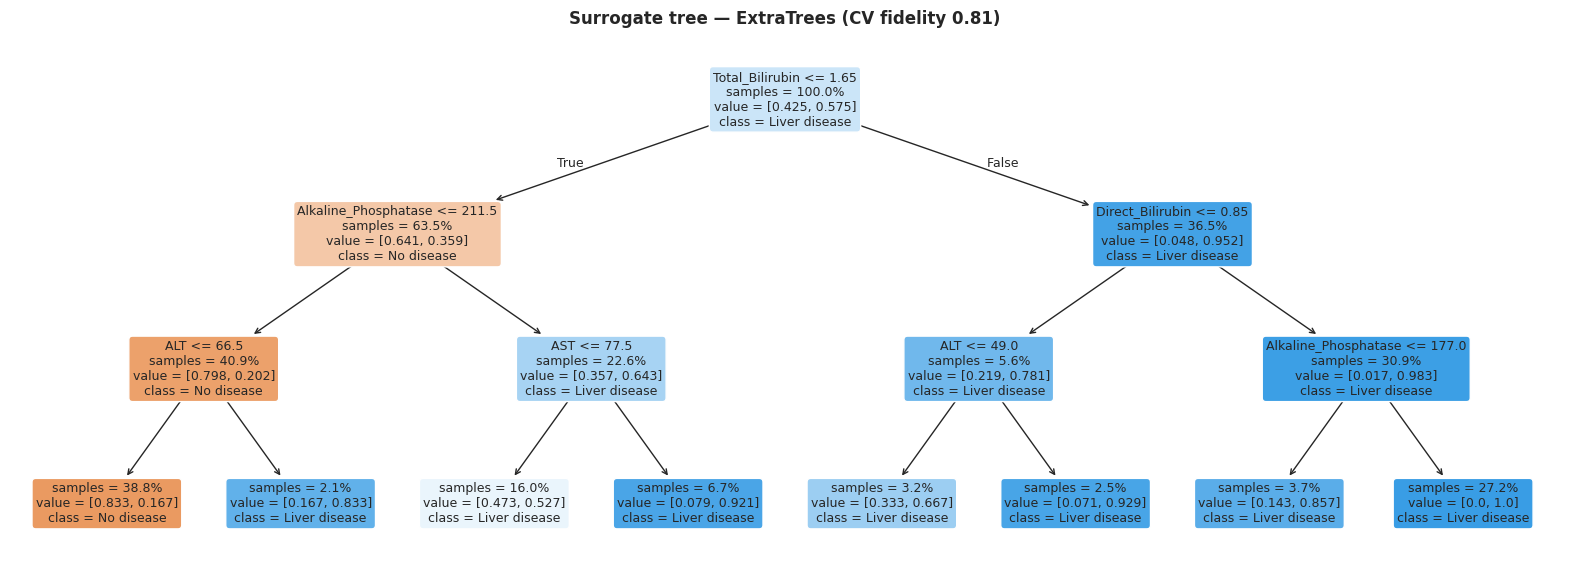

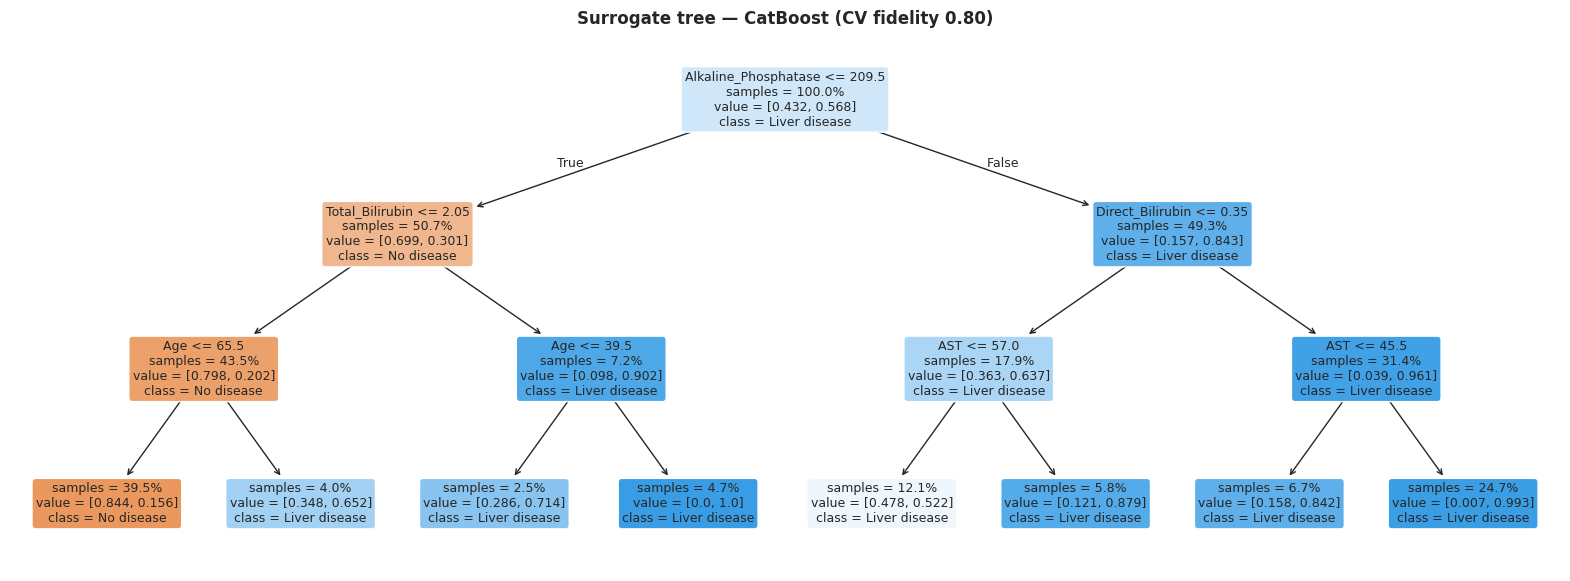

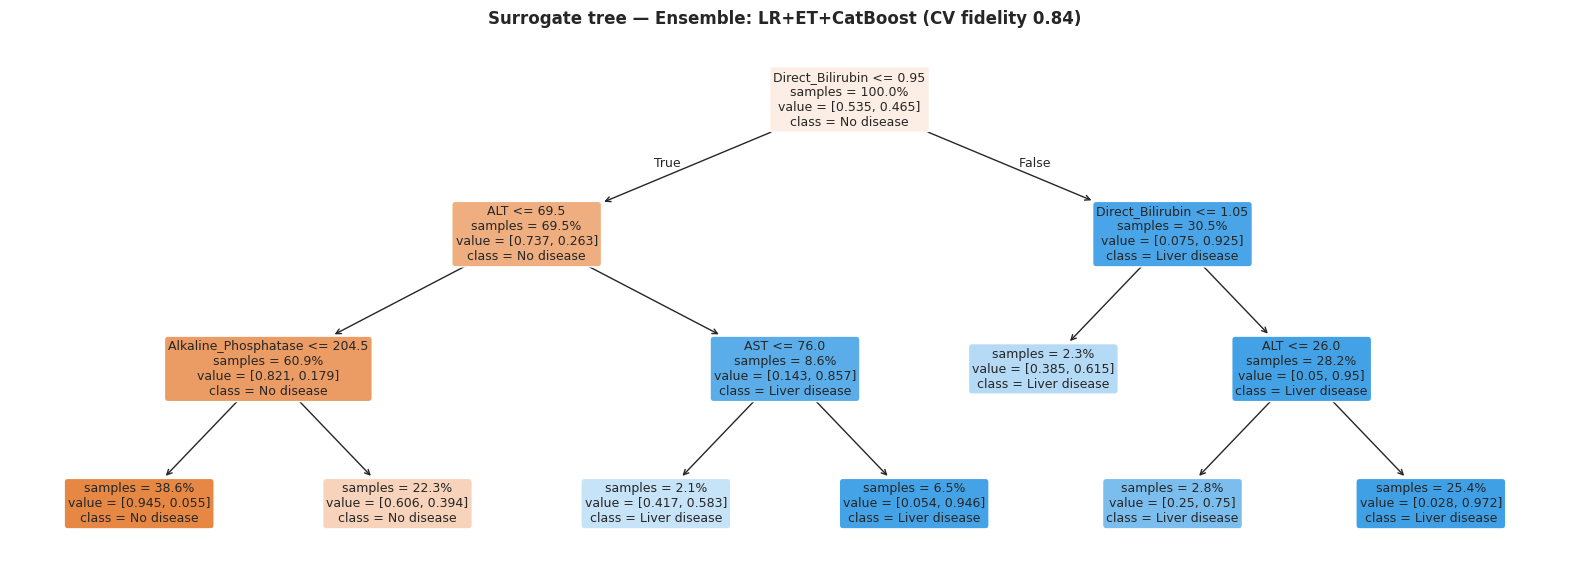

,fidelity_cv,share_predicted_disease
model,,
ExtraTrees,0.8088,0.5754
CatBoost,0.8018,0.5684
Ensemble: LR+ET+CatBoost,0.8368,0.4649


|--- Direct_Bilirubin <= 0.95
|   |--- ALT <= 69.50
|   |   |--- Alkaline_Phosphatase <= 204.50
|   |   |   |--- class: 0
|   |   |--- Alkaline_Phosphatase >  204.50
|   |   |   |--- class: 0
|   |--- ALT >  69.50
|   |   |--- AST <= 76.00
|   |   |   |--- class: 1
|   |   |--- AST >  76.00
|   |   |   |--- class: 1
|--- Direct_Bilirubin >  0.95
|   |--- Direct_Bilirubin <= 1.05
|   |   |--- class: 1
|   |--- Direct_Bilirubin >  1.05
|   |   |--- ALT <= 26.00
|   |   |   |--- class: 1
|   |   |--- ALT >  26.00
|   |   |   |--- class: 1



In [20]:
# ============================================================
# 17a. Surrogate decision trees
# ============================================================
CLIN = repair_ag(X)[FEATURES]
CLIN = CLIN.fillna(CLIN.median())
PROP = FINAL_MODEL
def f_prop(A):
    return PROP.predict_proba(pd.DataFrame(np.asarray(A, float), columns=FEATURES))[:, 1]

targets = OrderedDict((m, FINAL_MODEL.named_estimators_[m]) for m in FINAL_MEMBERS if m in ("ExtraTrees", "CatBoost", "TabPFN"))
targets[FINAL_VIEW] = FINAL_MODEL
SUR_ROWS, SURROGATES = [], {}
for name, est in targets.items():
    thr = FINAL_THRESHOLDS["balanced_accuracy"] if name == FINAL_VIEW else 0.5
    labels = (est.predict_proba(CLIN)[:, 1] >= thr).astype(int)
    sur = DecisionTreeClassifier(max_depth=3, min_samples_leaf=max(10, int(0.02 * N)), random_state=SEED)
    fid = cross_val_score(sur, CLIN, labels, cv=StratifiedKFold(5, shuffle=True, random_state=SEED), scoring="accuracy") \
        if len(np.unique(labels)) > 1 else np.array([1.0])
    sur.fit(CLIN, labels); SURROGATES[name] = sur
    SUR_ROWS.append({"model": name, "fidelity_cv": fid.mean(), "share_predicted_disease": labels.mean()})
    plt.figure(figsize=(20, 7))
    plot_tree(sur, feature_names=FEATURES, class_names=["No disease", "Liver disease"], filled=True, rounded=True,
              impurity=False, proportion=True, fontsize=9)
    plt.title(f"Surrogate tree — {name} (CV fidelity {fid.mean():.2f})"); save_fig(f"surrogate_{SHORT.get(name, 'final')}"); plt.show()
SURROGATE_TABLE = pd.DataFrame(SUR_ROWS).set_index("model")
display(SURROGATE_TABLE)
print(export_text(SURROGATES[FINAL_VIEW], feature_names=FEATURES, decimals=2))

In [ ]:
# ============================================================
# 17b. SHAP (global + local)
# ============================================================
_probe = pd.concat([CLIN] * 4, ignore_index=True).iloc[:2000]
t0 = time.perf_counter(); f_prop(_probe.values); T_ROW = (time.perf_counter() - t0) / len(_probe)
print(f"Final model prediction cost: {T_ROW * 1e6:.1f} µs per row")
SHAP_IMPORTANCE, SHAP_DIRECTION = None, None
if shap is not None:
    M = len(FEATURES); n_bg = 50; max_evals = 2 * M * 8 + 1
    n_explain = int(np.clip(SHAP_TIME_BUDGET_S / max(T_ROW * max_evals * n_bg, 1e-9), 20, N))
    if n_explain == 20 and T_ROW * max_evals * n_bg * 20 > SHAP_TIME_BUDGET_S:
        n_bg = 20
    bg = CLIN.sample(n_bg, random_state=SEED).values
    idx = np.random.default_rng(SEED).permutation(N)[:n_explain]
    explainer = shap.Explainer(f_prop, shap.maskers.Independent(bg), algorithm="permutation", feature_names=FEATURES, seed=SEED)
    SV = explainer(CLIN.values[idx], max_evals=max_evals, silent=True)
    print(f"SHAP: {n_explain} patients, background {n_bg}")
    SHAP_IMPORTANCE = pd.Series(np.abs(SV.values).mean(axis=0), index=FEATURES)
    SHAP_DIRECTION = pd.Series([stats.spearmanr(SV.data[:, j], SV.values[:, j])[0] if np.std(SV.data[:, j]) > 0 else 0.0
                                for j in range(M)], index=FEATURES)
    shap.plots.bar(SV, max_display=M, show=False); plt.title("Mean |SHAP| — final model"); save_fig("shap_bar"); plt.show()
    shap.plots.beeswarm(SV, max_display=M, show=False); plt.title("SHAP beeswarm — final model"); save_fig("shap_beeswarm"); plt.show()
    shap.plots.waterfall(SV[int(np.argmax(SV.values.sum(axis=1)))], max_display=M, show=False)
    plt.title("Local SHAP — highest-risk explained patient"); save_fig("shap_waterfall"); plt.show()
else:
    print("[INFO] shap not available.")

Final model prediction cost: 55.5 µs per row


In [ ]:
# ============================================================
# 17c. LIME (local cases + global aggregate)
# ============================================================
LIME_IMPORTANCE = None
if lime_tabular is not None:
    gi = FEATURES.index("Gender")
    lime_exp = lime_tabular.LimeTabularExplainer(
        CLIN.values, feature_names=FEATURES, class_names=["No disease", "Liver disease"], categorical_features=[gi],
        categorical_names={gi: list(GENDER_ENCODER.classes_)}, discretize_continuous=True, mode="classification",
        random_state=SEED)
    predict_fn = lambda A: PROP.predict_proba(pd.DataFrame(np.asarray(A, float), columns=FEATURES))
    LIME_SAMPLES = 2000 if T_ROW * 2000 < 5 else 800
    # cases are chosen from honest repeat-0 out-of-fold decisions, then explained with the final model
    p_all = f_prop(CLIN.values)
    p_oof0, pred = PROB0[FINAL_VIEW], PRED0[FINAL_VIEW]["balanced_accuracy"]
    cases = OrderedDict()
    for cname, mask, pick in [("True positive", (pred == 1) & (y == 1), np.argmax), ("True negative", (pred == 0) & (y == 0), np.argmin),
                              ("False negative", (pred == 0) & (y == 1), np.argmin), ("False positive", (pred == 1) & (y == 0), np.argmax)]:
        ids = np.where(mask)[0]
        if len(ids):
            cases[cname] = ids[pick(p_oof0[ids])]
    for cname, i in cases.items():
        ex = lime_exp.explain_instance(CLIN.values[i], predict_fn, num_features=len(FEATURES), num_samples=LIME_SAMPLES)
        fig = ex.as_pyplot_figure(label=1); fig.set_size_inches(8, 4)
        plt.title(f"LIME — {cname} (OOF): patient #{i}, OOF P={p_oof0[i]:.2f}, final-model P={p_all[i]:.2f}"); plt.tight_layout()
        save_fig(f"lime_{cname.replace(' ', '_').lower()}"); plt.show()
        print(cname, "->", [(r_, round(w, 3)) for r_, w in ex.as_list(label=1)])
    n_glob = int(np.clip(LIME_TIME_BUDGET_S / max(T_ROW * LIME_SAMPLES, 1e-9), 10, 60))
    agg = np.zeros(len(FEATURES))
    for i in np.random.default_rng(SEED).permutation(N)[:n_glob]:
        ex = lime_exp.explain_instance(CLIN.values[i], predict_fn, num_features=len(FEATURES), num_samples=LIME_SAMPLES)
        for fidx, w in ex.as_map()[1]:
            agg[fidx] += abs(w) / n_glob
    LIME_IMPORTANCE = pd.Series(agg, index=FEATURES)
    display(LIME_IMPORTANCE.sort_values(ascending=False).to_frame("mean_abs_LIME_weight"))
else:
    print("[INFO] lime not available.")

In [ ]:
# ============================================================
# 17d. Morris sensitivity + CV permutation importance
# ============================================================
MORRIS_TABLE = None
if salib_sample is not None and salib_analyze is not None:
    MF = [c for c in FEATURES if c != "Gender"]
    bounds = []
    for c in MF:
        lo, hi = np.percentile(CLIN[c], [1, 99]); bounds.append([float(lo), float(hi if hi > lo else lo + 1e-3)])
    problem = {"num_vars": len(MF), "names": MF, "bounds": bounds}
    Xm = salib_sample.sample(problem, N=100, num_levels=4, seed=SEED)
    full = pd.DataFrame(Xm, columns=MF); full["Gender"] = float(CLIN["Gender"].mode()[0])
    Si = salib_analyze.analyze(problem, Xm, f_prop(full[FEATURES].values), num_resamples=1000, conf_level=0.95,
                               num_levels=4, seed=SEED)
    MORRIS_TABLE = pd.DataFrame({"mu": Si["mu"], "mu_star": Si["mu_star"], "sigma": Si["sigma"],
                                 "mu_star_conf95": Si["mu_star_conf"]}, index=MF).sort_values("mu_star", ascending=False)
    display(MORRIS_TABLE)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    MORRIS_TABLE["mu_star"][::-1].plot.barh(xerr=MORRIS_TABLE["mu_star_conf95"][::-1], ax=axes[0], color="#2E86AB", capsize=3)
    axes[0].set_xlabel("μ* ± 95% CI"); axes[0].set_title("Morris importance")
    axes[1].scatter(MORRIS_TABLE["mu_star"], MORRIS_TABLE["sigma"], color="#E4572E")
    for c, rr in MORRIS_TABLE.iterrows():
        axes[1].annotate(c, (rr["mu_star"], rr["sigma"]), fontsize=8, xytext=(3, 3), textcoords="offset points")
    axes[1].set_xlabel("μ*"); axes[1].set_ylabel("σ"); axes[1].set_title("Morris μ*–σ")
    plt.tight_layout(); save_fig("morris"); plt.show()

PERM_REPEATS = 5 if "TabPFN" in FINAL_MEMBERS else 20      # TabPFN prediction is slow on CPU
def _perm_task(tr, va, seed, X, y, CLIN, members):
    ens = VotingClassifier([(m, build_member(m, seed)) for m in members], voting="soft").fit(X.iloc[tr], y[tr])
    return permutation_importance(ens, CLIN.iloc[va], y[va], scoring="roc_auc", n_repeats=PERM_REPEATS,
                                  random_state=seed, n_jobs=1).importances_mean
perm = np.array(Parallel(n_jobs=1 if "TabPFN" in FINAL_MEMBERS else N_JOBS)(
    delayed(_perm_task)(tr, va, SEED, X, y, CLIN, FINAL_MEMBERS) for r, k, tr, va in OUTER if r == 0))
PERM_TABLE = pd.DataFrame({"AUC_drop_mean": perm.mean(0), "AUC_drop_sd_over_folds": perm.std(0, ddof=1)},
                          index=FEATURES).sort_values("AUC_drop_mean", ascending=False)
display(PERM_TABLE)

## 18. Consensus clinical risk factors

In [ ]:
# ============================================================
# 18. Consensus of SHAP, LIME, Morris and permutation importance
# ============================================================
IMP = pd.DataFrame(index=FEATURES)
if SHAP_IMPORTANCE is not None:
    IMP["SHAP_mean_abs"] = SHAP_IMPORTANCE
if LIME_IMPORTANCE is not None:
    IMP["LIME_mean_abs"] = LIME_IMPORTANCE
if MORRIS_TABLE is not None:
    IMP["Morris_mu_star"] = MORRIS_TABLE["mu_star"]
IMP["Permutation_AUC_drop_CV"] = PERM_TABLE["AUC_drop_mean"].clip(lower=0)
methods = list(IMP.columns)
RANKS = IMP.rank(ascending=False, na_option="keep")
IMP["consensus_rank"] = RANKS.mean(axis=1, skipna=True)
IMP["n_methods"] = RANKS.notna().sum(axis=1)
direction = (SHAP_DIRECTION if SHAP_DIRECTION is not None else
             MORRIS_TABLE["mu"].reindex(FEATURES).fillna(0) if MORRIS_TABLE is not None else pd.Series(0.0, index=FEATURES))
IMP["effect_on_disease_risk"] = [("higher value -> higher risk" if d > 0.1 else "higher value -> lower risk" if d < -0.1
                                  else "weak / non-monotone") for d in direction.reindex(FEATURES).fillna(0)]
if SHAP_DIRECTION is not None:
    IMP.loc["Gender", "effect_on_disease_risk"] = ("male -> higher risk" if direction["Gender"] > 0.1 else
                                                   "female -> higher risk" if direction["Gender"] < -0.1 else "weak")
IMP = IMP.sort_values("consensus_rank")
display(IMP)
plt.figure(figsize=(9, 0.45 * len(FEATURES) + 1.5))
sns.heatmap(IMP[methods] / IMP[methods].max(), annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={"label": "importance / max"})
plt.title("Explainability consensus — final model"); save_fig("importance_consensus"); plt.show()
TOP_RISK = IMP.head(5)
EVIDENCE["risk_factors"] = IMP[["consensus_rank", "effect_on_disease_risk"]].reset_index().rename(
    columns={"index": "feature"}).to_dict(orient="records")

## 19. Final summary and exports

In [ ]:
# ============================================================
# 19. Summary + exports
# ============================================================
fv = EVAL[EVAL["view"] == FINAL_VIEW]
print("=" * 100)
print("ILPD LIVER DISEASE PREDICTION — FRAMEWORK v2 SUMMARY")
print("=" * 100)
print(f"Data: {EVIDENCE['data']['rows_unique']} unique patients; column mapping by {EVIDENCE['column_mapping']['method']} "
      f"({len(EVIDENCE['column_mapping']['overridden_headers'])} headers corrected)")
print(f"Validation: repeated stratified {N_FOLDS}-fold x {N_REPEATS} ({len(OUTER)} outer fits), nested thresholds and LR penalty")
print(f"Final model: {FINAL_VIEW}")
print(f"  ROC-AUC  {DISC.loc[FINAL_VIEW, 'AUC']:.3f} {DISC.loc[FINAL_VIEW, 'AUC_95CI']} | repeat SD {DISC.loc[FINAL_VIEW, 'AUC_repeat_SD']:.3f}"
      f" | Brier {DISC.loc[FINAL_VIEW, 'Brier']:.3f} (no-skill {PI_ALL * (1 - PI_ALL):.3f})")
for rule, rlabel in RULES.items():
    s = fv[fv["rule"] == rule]
    print(f"  {rlabel:<28} acc {fmt_ci(s['Accuracy'])} | sens {s['Recall_TPR'].mean():.3f} | spec {s['TNR'].mean():.3f}"
          f" | BA {s['Balanced_Acc'].mean():.3f} | MCC {s['MCC'].mean():.3f}")
bt = BASELINE_TESTS.loc[FINAL_VIEW]
print(f"  Accuracy gain over 'everyone diseased': {bt['gain_vs_majority']:+.3f} (corrected p = {bt['p_gain (corrected)']:.3f})")
print(f"  Risk-coverage: {'90% accuracy at ' + format(COV90, '.0%') + ' coverage' if COV90 else '90% accuracy not reached at any coverage'}")
print("  Learning curve:", "; ".join(f"{m}: {v['verdict']} ({v['gain_70_to_100pct']:+.3f})" for m, v in lc_verdict.items()))
for e, rr in EXPERIMENTS.iterrows():
    print(f"  {e}: dAUC {rr['mean_dAUC']:+.4f} (p = {rr['p_corrected']:.3f})")
print("  Top risk factors:", ", ".join(f"{f} ({r_['effect_on_disease_risk']})" for f, r_ in TOP_RISK.iterrows()))
print(f"Total runtime: {(time.time() - T_START) / 60:.1f} min")
print("=" * 100)

for name_, obj in [("discrimination", DISC), ("baseline_tests", BASELINE_TESTS), ("ablation", ABLATION),
                   ("ttests", TTESTS), ("bowker_errors", BOWKER_ERRORS), ("bowker_pairs", BOWKER_PAIRS),
                   ("learning_curve", LC_SUM), ("experiments_noise_parsimony", EXPERIMENTS),
                   ("surrogate_fidelity", SURROGATE_TABLE), ("permutation_importance_cv", PERM_TABLE),
                   ("importance_consensus", IMP)]:
    obj.to_csv(os.path.join(OUT_DIR, f"{name_}.csv"))
for v, tab in RC.items():
    tab.to_csv(os.path.join(OUT_DIR, f"risk_coverage_{SHORT.get(v, 'final')}.csv"))
if MORRIS_TABLE is not None:
    MORRIS_TABLE.to_csv(os.path.join(OUT_DIR, "morris.csv"))
with open(os.path.join(OUT_DIR, "final_thresholds.json"), "w") as fh:
    json.dump({"final_view": FINAL_VIEW, "members": FINAL_MEMBERS, "scale": "balanced-prior probability",
               "thresholds": FINAL_THRESHOLDS, "training_prevalence": PI_ALL}, fh, indent=2)
with open(os.path.join(OUT_DIR, "evidence_and_decisions.json"), "w") as fh:
    json.dump(EVIDENCE, fh, indent=2, default=lambda o: o.item() if hasattr(o, "item") else str(o))
try:
    import joblib
    joblib.dump(FINAL_MODEL, os.path.join(OUT_DIR, "final_model.joblib"))
except Exception as exc:
    print(f"[WARN] model not saved: {exc}")
print("Saved results, figures, OOF predictions, thresholds and the final model to", OUT_DIR)